In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
appointments = pd.read_csv("apollo_appointments_fact.csv")
doctors = pd.read_csv("apollo_doctors_dim.csv")

print("Appointments Dataset:", appointments.shape)
print("Doctors Dataset:", doctors.shape)

Appointments Dataset: (75000, 52)
Doctors Dataset: (320, 15)


In [3]:
# Check first 5 rows of appointments data
appointments.head()

,appointment_id,patient_id,doctor_id,appointment_date,appointment_day,appointment_day_of_week,appointment_month,appointment_quarter,appointment_year,appointment_hour,...,insurance_coverage,insurance_provider,insurance_covered_amount,patient_out_of_pocket,revenue_realized,payment_mode,wait_time_minutes,consultation_duration_min,patient_satisfaction_score,doctor_utilization_pct
0,APPT5000001,PAT117608,DOC1035,2023-11-15,Wednesday,2,11,Q4,2023,15,...,No,NaN,0,2700,2700,UPI,11.0,40.0,4.8,84.2
1,APPT5000002,PAT128732,DOC1049,2023-03-13,Monday,0,3,Q1,2023,9,...,No,NaN,0,1400,1400,UPI,21.0,18.0,4.1,64.5
2,APPT5000003,PAT137532,DOC1033,2022-02-07,Monday,0,2,Q1,2022,17,...,No,NaN,0,600,600,Net Banking,6.0,6.0,5.0,75.6
3,APPT5000004,PAT113284,DOC1288,2023-11-20,Monday,0,11,Q4,2023,17,...,No,NaN,0,1275,1275,UPI,2.0,25.0,4.4,68.6
4,APPT5000005,PAT107443,DOC1064,2024-02-02,Friday,4,2,Q1,2024,19,...,No,NaN,0,1700,1700,Cash,7.0,13.0,3.5,67.7


In [4]:
# Check first 5 rows of doctors data
doctors.head()

,doctor_id,doctor_name,specialty,qualification,experience_years,city,state,hospital_name,consultation_fee,rating,total_reviews,available_days,avg_slot_duration_min,accepts_insurance,teleconsult_enabled
0,DOC1001,Dr. Deepa Sharma,Urology,"MBBS, MCh",12,Bengaluru,Karnataka,Apollo Hospital Bannerghatta,2300,4.4,1502,Mon-Fri,15,Yes,No
1,DOC1002,Dr. Venkatesan Khan,Paediatrics,"MBBS, MS, FRCS",25,Chandigarh,Punjab,Apollo Clinic Sector 8,1200,4.5,2453,Mon-Sat,10,Yes,Yes
2,DOC1003,Dr. Pradeep Menon,General Physician,"MBBS, DM",13,Mumbai,Maharashtra,Apollo Clinic Andheri,700,4.7,995,Mon-Wed-Fri-Sat,15,No,No
3,DOC1004,Dr. Vivek Mathew,General Physician,"MBBS, MD",31,Mumbai,Maharashtra,Apollo Hospital Navi Mumbai,1000,4.9,666,Mon-Wed-Fri-Sat,20,Yes,Yes
4,DOC1005,Dr. Savita Philip,General Physician,"MBBS, MD, PhD",5,Mumbai,Maharashtra,Apollo Hospital Navi Mumbai,600,4.5,1383,Mon-Sat,30,Yes,Yes


In [5]:
# Check column names
print("Appointment Columns:")
print(appointments.columns.tolist())

print("\nDoctor Columns:")
print(doctors.columns.tolist())

Appointment Columns:
['appointment_id', 'patient_id', 'doctor_id', 'appointment_date', 'appointment_day', 'appointment_day_of_week', 'appointment_month', 'appointment_quarter', 'appointment_year', 'appointment_hour', 'appointment_minute', 'time_slot', 'time_of_day', 'booking_date', 'booking_lead_days', 'booking_channel', 'appointment_type', 'specialty', 'city', 'state', 'hospital_name', 'patient_age', 'age_group', 'patient_gender', 'patient_city_tier', 'patient_chronic_condition', 'apollo_member', 'membership_type', 'reminder_type', 'reminders_sent', 'patient_prior_visits', 'patient_prior_no_shows', 'is_first_visit', 'repeat_visit', 'visit_reason', 'appointment_status', 'no_show', 'no_show_flag', 'cancellation_reason', 'consultation_fee', 'discount_pct', 'actual_fee_charged', 'insurance_coverage', 'insurance_provider', 'insurance_covered_amount', 'patient_out_of_pocket', 'revenue_realized', 'payment_mode', 'wait_time_minutes', 'consultation_duration_min', 'patient_satisfaction_score', 

In [6]:
# Dataset information
print("APPOINTMENTS DATASET INFO")
appointments.info()

print("\n" + "="*60 + "\n")

print("DOCTORS DATASET INFO")
doctors.info()

APPOINTMENTS DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 52 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   appointment_id              75000 non-null  str    
 1   patient_id                  75000 non-null  str    
 2   doctor_id                   75000 non-null  str    
 3   appointment_date            75000 non-null  str    
 4   appointment_day             75000 non-null  str    
 5   appointment_day_of_week     75000 non-null  int64  
 6   appointment_month           75000 non-null  int64  
 7   appointment_quarter         75000 non-null  str    
 8   appointment_year            75000 non-null  int64  
 9   appointment_hour            75000 non-null  int64  
 10  appointment_minute          75000 non-null  int64  
 11  time_slot                   75000 non-null  str    
 12  time_of_day                 75000 non-null  str    
 13  booking_date    

In [7]:
# Check duplicate rows
print("Duplicate rows in appointments:", appointments.duplicated().sum())
print("Duplicate rows in doctors:", doctors.duplicated().sum())

print("\n" + "="*60)

# Check duplicate IDs
print("Duplicate appointment IDs:", appointments["appointment_id"].duplicated().sum())
print("Duplicate patient IDs:", appointments["patient_id"].duplicated().sum())
print("Duplicate doctor IDs in appointments:", appointments["doctor_id"].duplicated().sum())
print("Duplicate doctor IDs in doctors:", doctors["doctor_id"].duplicated().sum())

Duplicate rows in appointments: 0
Duplicate rows in doctors: 0

Duplicate appointment IDs: 0
Duplicate patient IDs: 42295
Duplicate doctor IDs in appointments: 74680
Duplicate doctor IDs in doctors: 0


In [8]:
# Check missing values in appointments dataset

missing_values = appointments.isnull().sum()
missing_percentage = (appointments.isnull().sum() / len(appointments)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_summary = missing_summary[missing_summary["Missing Values"] > 0]

missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Missing Percentage
cancellation_reason,69207,92.276000
membership_type,58225,77.633333
insurance_provider,51512,68.682667
patient_chronic_condition,28038,37.384000
wait_time_minutes,19725,26.300000
patient_satisfaction_score,19725,26.300000
consultation_duration_min,19725,26.300000
doctor_utilization_pct,19725,26.300000
no_show,2348,3.130667


In [9]:
# Check appointment status distribution
print("Appointment Status:")
print(appointments["appointment_status"].value_counts(dropna=False))

print("\n" + "="*60)

# Check no_show values
print("No-Show Column:")
print(appointments["no_show"].value_counts(dropna=False))

Appointment Status:
appointment_status
Completed    55275
No-Show      11584
Cancelled     5793
Scheduled     2348
Name: count, dtype: int64

No-Show Column:
no_show
No     61068
Yes    11584
NaN     2348
Name: count, dtype: int64


In [10]:
# Convert date columns to datetime format

appointments["appointment_date"] = pd.to_datetime(
    appointments["appointment_date"]
)

appointments["booking_date"] = pd.to_datetime(
    appointments["booking_date"]
)

# Check data types
print("Appointment Date Type:", appointments["appointment_date"].dtype)
print("Booking Date Type:", appointments["booking_date"].dtype)

Appointment Date Type: datetime64[us]
Booking Date Type: datetime64[us]


In [11]:
# Check whether any booking date is after the appointment date

invalid_booking_dates = (
    appointments["booking_date"] > appointments["appointment_date"]
).sum()

print("Invalid booking dates:", invalid_booking_dates)

Invalid booking dates: 0


In [12]:
# Calculate booking lead days independently

calculated_lead_days = (
    appointments["appointment_date"] - appointments["booking_date"]
).dt.days

# Compare calculated value with existing booking_lead_days
lead_days_difference = (
    calculated_lead_days - appointments["booking_lead_days"]
)

print("Mismatched booking lead days:", (lead_days_difference != 0).sum())
print("Minimum booking lead days:", appointments["booking_lead_days"].min())
print("Maximum booking lead days:", appointments["booking_lead_days"].max())

Mismatched booking lead days: 0
Minimum booking lead days: 0
Maximum booking lead days: 30


In [13]:
# Check unique values in important categorical columns

categorical_columns = [
    "booking_channel",
    "appointment_type",
    "specialty",
    "city",
    "time_of_day",
    "apollo_member",
    "reminder_type",
    "repeat_visit",
    "appointment_status",
    "insurance_coverage",
    "payment_mode",
    "patient_gender"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(appointments[column].value_counts(dropna=False))


booking_channel:
booking_channel
Apollo App     34042
Website        18545
Call Centre    11201
Walk-In         7501
Partner App     3711
Name: count, dtype: int64

appointment_type:
appointment_type
In-Clinic        49097
Video Consult    15833
Home Visit       10070
Name: count, dtype: int64

specialty:
specialty
General Physician    20272
Dermatology           7824
Paediatrics           6382
Orthopaedics          5589
ENT                   5385
Neurology             4993
Cardiology            4641
Gynaecology           4113
Ophthalmology         3193
Psychiatry            2989
Pulmonology           2624
Gastroenterology      2621
Urology               2287
Endocrinology         2087
Name: count, dtype: int64

city:
city
Delhi         10757
Mumbai        10043
Bengaluru      8627
Hyderabad      7439
Chennai        6893
Kolkata        5872
Pune           4141
Ahmedabad      3585
Lucknow        3100
Kochi          2776
Jaipur         2736
Chandigarh     2485
Coimbatore     2241
Indore

In [14]:
# Basic validation of numerical columns

print("Patient Age:")
print("Minimum:", appointments["patient_age"].min())
print("Maximum:", appointments["patient_age"].max())

print("\nBooking Lead Days:")
print("Minimum:", appointments["booking_lead_days"].min())
print("Maximum:", appointments["booking_lead_days"].max())

print("\nReminders Sent:")
print("Minimum:", appointments["reminders_sent"].min())
print("Maximum:", appointments["reminders_sent"].max())

print("\nPatient Prior Visits:")
print("Minimum:", appointments["patient_prior_visits"].min())
print("Maximum:", appointments["patient_prior_visits"].max())

print("\nPatient Prior No-Shows:")
print("Minimum:", appointments["patient_prior_no_shows"].min())
print("Maximum:", appointments["patient_prior_no_shows"].max())

print("\nConsultation Fee:")
print("Minimum:", appointments["consultation_fee"].min())
print("Maximum:", appointments["consultation_fee"].max())

print("\nDiscount %:")
print("Minimum:", appointments["discount_pct"].min())
print("Maximum:", appointments["discount_pct"].max())

Patient Age:
Minimum: 1
Maximum: 85

Booking Lead Days:
Minimum: 0
Maximum: 30

Reminders Sent:
Minimum: 0
Maximum: 3

Patient Prior Visits:
Minimum: 0
Maximum: 9

Patient Prior No-Shows:
Minimum: 0
Maximum: 6

Consultation Fee:
Minimum: 425
Maximum: 5400

Discount %:
Minimum: 0
Maximum: 20


In [15]:
# Validate quality metrics against appointment status

quality_columns = [
    "wait_time_minutes",
    "consultation_duration_min",
    "patient_satisfaction_score",
    "doctor_utilization_pct"
]

for column in quality_columns:
    non_completed_values = appointments.loc[
        appointments["appointment_status"] != "Completed",
        column
    ].notna().sum()
    
    print(f"{column}:")
    print(f"Non-null values in non-Completed appointments: {non_completed_values}")
    print()

wait_time_minutes:
Non-null values in non-Completed appointments: 0

consultation_duration_min:
Non-null values in non-Completed appointments: 0

patient_satisfaction_score:
Non-null values in non-Completed appointments: 0

doctor_utilization_pct:
Non-null values in non-Completed appointments: 0



In [16]:
# Financial data validation

financial_columns = [
    "actual_fee_charged",
    "insurance_covered_amount",
    "patient_out_of_pocket",
    "revenue_realized"
]

print("Revenue in Non-Completed appointments:")

non_completed = appointments[
    appointments["appointment_status"] != "Completed"
]

for column in financial_columns:
    print(
        f"{column}:",
        (non_completed[column] != 0).sum()
    )

print("\n" + "="*60)

print("Minimum values:")

for column in financial_columns:
    print(
        f"{column}:",
        appointments[column].min()
    )

Revenue in Non-Completed appointments:
actual_fee_charged: 0
insurance_covered_amount: 0
patient_out_of_pocket: 0
revenue_realized: 0

Minimum values:
actual_fee_charged: 0
insurance_covered_amount: 0
patient_out_of_pocket: 0
revenue_realized: 0


In [17]:
# Check whether all appointment doctor IDs exist in doctors dataset

appointment_doctor_ids = set(appointments["doctor_id"])
doctor_dimension_ids = set(doctors["doctor_id"])

missing_doctor_ids = appointment_doctor_ids - doctor_dimension_ids

print("Unique doctors in appointments:", len(appointment_doctor_ids))
print("Doctors in doctors dataset:", len(doctor_dimension_ids))
print("Doctor IDs missing from doctors dataset:", len(missing_doctor_ids))

Unique doctors in appointments: 320
Doctors in doctors dataset: 320
Doctor IDs missing from doctors dataset: 0


In [18]:
# Merge appointments data with doctors data

df = appointments.merge(
    doctors,
    on="doctor_id",
    how="left",
    suffixes=("_appointment", "_doctor")
)

print("Merged Dataset Shape:", df.shape)
print("Missing Doctor Records:", df["doctor_name"].isna().sum())

Merged Dataset Shape: (75000, 66)
Missing Doctor Records: 0


In [19]:
# Monthly appointment volume

monthly_appointments = (
    df.groupby(
        ["appointment_year", "appointment_month"]
    )
    .size()
    .reset_index(name="appointment_count")
)

monthly_appointments

,appointment_year,appointment_month,appointment_count
0,2022,1,2426
1,2022,2,2012
2,2022,3,2085
3,2022,4,1926
4,2022,5,2033
5,2022,6,1823
6,2022,7,1833
7,2022,8,1835
8,2022,9,2115
9,2022,10,2206


In [20]:
# Create a date column for monthly trend visualization

monthly_appointments["month_date"] = pd.to_datetime(
    monthly_appointments["appointment_year"].astype(str)
    + "-"
    + monthly_appointments["appointment_month"].astype(str)
    + "-01"
)

monthly_appointments = monthly_appointments.sort_values("month_date")

monthly_appointments.head()

,appointment_year,appointment_month,appointment_count,month_date
0,2022,1,2426,2022-01-01
1,2022,2,2012,2022-02-01
2,2022,3,2085,2022-03-01
3,2022,4,1926,2022-04-01
4,2022,5,2033,2022-05-01


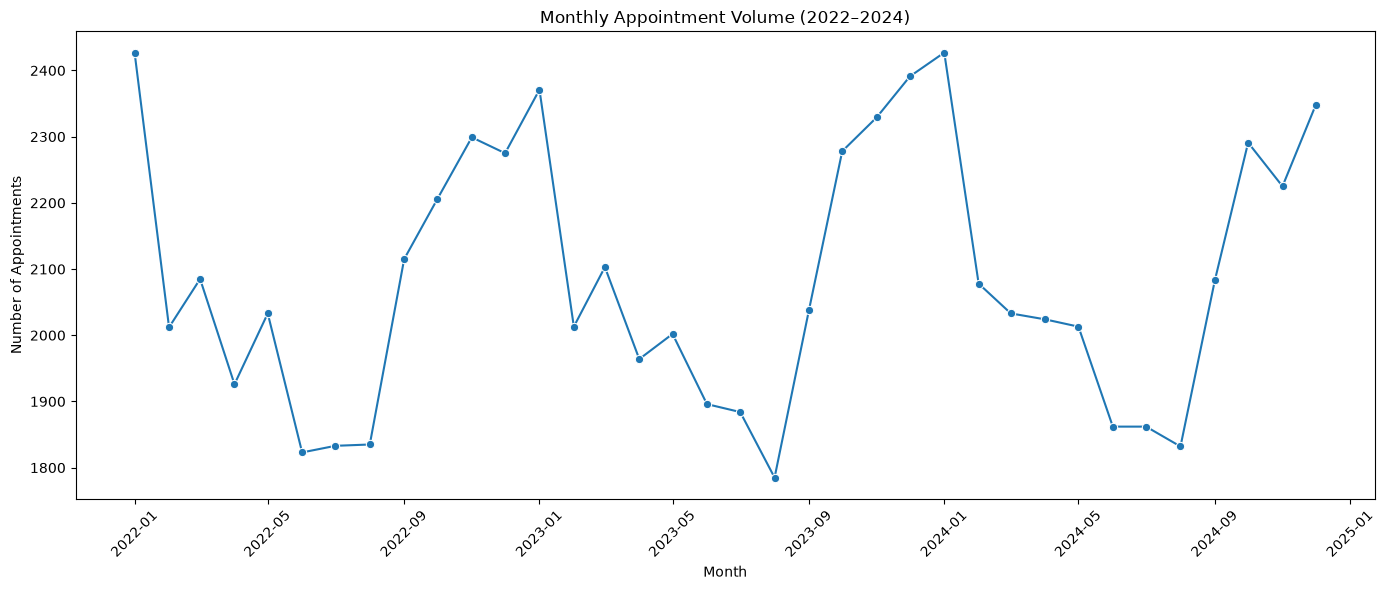

In [21]:
# Monthly appointment trend

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_appointments,
    x="month_date",
    y="appointment_count",
    marker="o"
)

plt.title("Monthly Appointment Volume (2022–2024)")
plt.xlabel("Month")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [22]:
# Year-wise appointment volume

yearly_appointments = (
    df.groupby("appointment_year")
      .size()
      .reset_index(name="appointment_count")
)

yearly_appointments

,appointment_year,appointment_count
0,2022,24868
1,2023,25054
2,2024,25078


In [23]:
# Calculate year-over-year growth

yearly_appointments["YoY_Growth_%"] = (
    yearly_appointments["appointment_count"]
    .pct_change() * 100
)

yearly_appointments

,appointment_year,appointment_count,YoY_Growth_%
0,2022,24868,NaN
1,2023,25054,0.747949
2,2024,25078,0.095793


In [24]:
# Quarter-wise appointment volume

quarterly_appointments = (
    df.groupby(
        ["appointment_year", "appointment_quarter"]
    )
    .size()
    .reset_index(name="appointment_count")
)

quarterly_appointments

,appointment_year,appointment_quarter,appointment_count
0,2022,Q1,6523
1,2022,Q2,5782
2,2022,Q3,5783
3,2022,Q4,6780
4,2023,Q1,6487
5,2023,Q2,5862
6,2023,Q3,5707
7,2023,Q4,6998
8,2024,Q1,6538
9,2024,Q2,5899


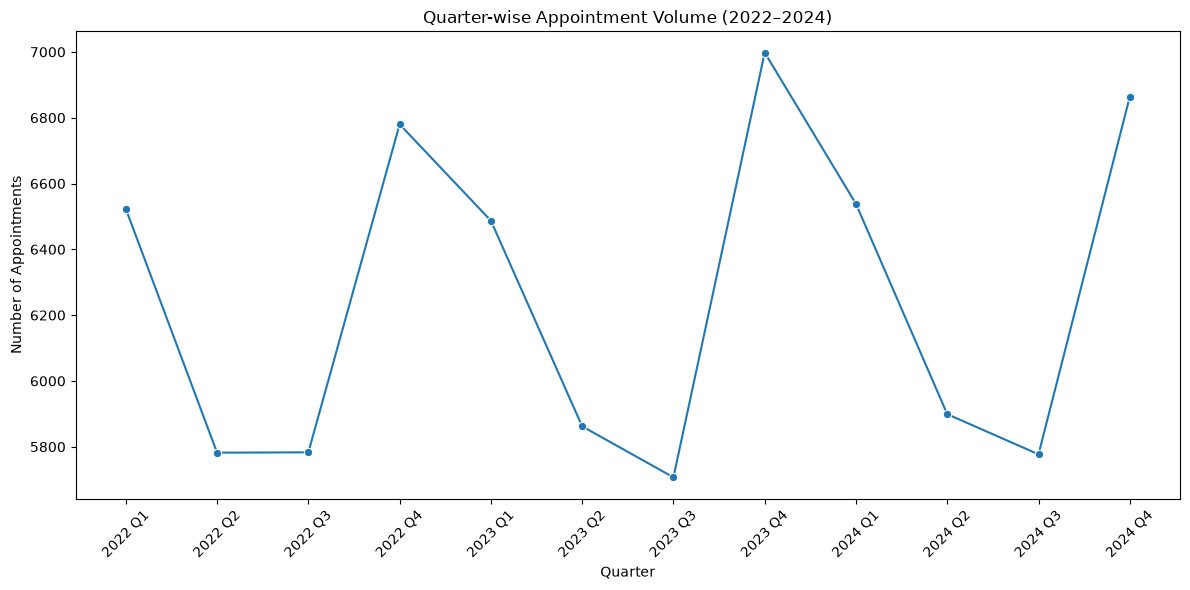

In [25]:
# Quarter-wise appointment volume trend

quarterly_appointments["quarter_label"] = (
    quarterly_appointments["appointment_year"].astype(str)
    + " "
    + quarterly_appointments["appointment_quarter"]
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=quarterly_appointments,
    x="quarter_label",
    y="appointment_count",
    marker="o"
)

plt.title("Quarter-wise Appointment Volume (2022–2024)")
plt.xlabel("Quarter")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [26]:
# Appointment outcome distribution

outcome_summary = (
    df["appointment_status"]
    .value_counts()
    .reset_index()
)

outcome_summary.columns = ["appointment_status", "appointment_count"]

# Calculate percentage
outcome_summary["percentage"] = (
    outcome_summary["appointment_count"]
    / outcome_summary["appointment_count"].sum()
) * 100

outcome_summary

,appointment_status,appointment_count,percentage
0,Completed,55275,73.700000
1,No-Show,11584,15.445333
2,Cancelled,5793,7.724000
3,Scheduled,2348,3.130667


In [27]:
# Calculate business-defined no-show rate

completed_count = (
    df["appointment_status"] == "Completed"
).sum()

no_show_count = (
    df["appointment_status"] == "No-Show"
).sum()

cancelled_count = (
    df["appointment_status"] == "Cancelled"
).sum()

no_show_rate = (
    no_show_count
    / (completed_count + no_show_count + cancelled_count)
) * 100

print("Completed:", completed_count)
print("No-Show:", no_show_count)
print("Cancelled:", cancelled_count)
print("No-Show Rate:", round(no_show_rate, 2), "%")

Completed: 55275
No-Show: 11584
Cancelled: 5793
No-Show Rate: 15.94 %


In [28]:
# No-show rate by booking channel

channel_no_show = (
    df[df["appointment_status"].isin(
        ["Completed", "No-Show", "Cancelled"]
    )]
    .groupby("booking_channel")
    .agg(
        total_eligible_appointments=("appointment_id", "count"),
        no_show_count=("appointment_status", lambda x: (x == "No-Show").sum())
    )
    .reset_index()
)

channel_no_show["no_show_rate_%"] = (
    channel_no_show["no_show_count"]
    / channel_no_show["total_eligible_appointments"]
) * 100

channel_no_show = channel_no_show.sort_values(
    "no_show_rate_%",
    ascending=False
)

channel_no_show

,booking_channel,total_eligible_appointments,no_show_count,no_show_rate_%
3,Walk-In,7281,1520,20.876253
2,Partner App,3594,651,18.113523
4,Website,17964,3090,17.201069
1,Call Centre,10855,1650,15.200368
0,Apollo App,32958,4673,14.178652


In [29]:
# No-show rate by specialty

specialty_no_show = (
    df[df["appointment_status"].isin(
        ["Completed", "No-Show", "Cancelled"]
    )]
    .groupby("specialty_appointment")
    .agg(
        total_eligible_appointments=("appointment_id", "count"),
        no_show_count=("appointment_status", lambda x: (x == "No-Show").sum())
    )
    .reset_index()
)

specialty_no_show["no_show_rate_%"] = (
    specialty_no_show["no_show_count"]
    / specialty_no_show["total_eligible_appointments"]
) * 100

specialty_no_show = specialty_no_show.sort_values(
    "no_show_rate_%",
    ascending=False
)

specialty_no_show

,specialty_appointment,total_eligible_appointments,no_show_count,no_show_rate_%
11,Psychiatry,2900,711,24.517241
1,Dermatology,7566,1608,21.252974
2,ENT,5211,988,18.959893
3,Endocrinology,2024,355,17.539526
8,Ophthalmology,3103,503,16.210119
5,General Physician,19654,3049,15.513381
12,Pulmonology,2549,394,15.457042
9,Orthopaedics,5419,810,14.947407
4,Gastroenterology,2527,377,14.918876
13,Urology,2222,320,14.401440


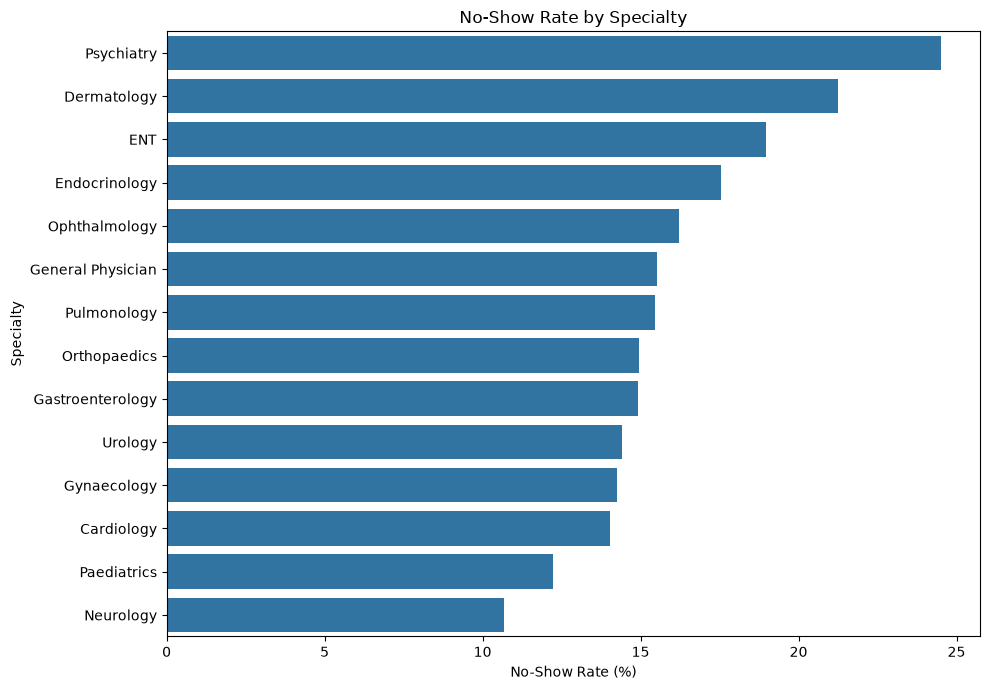

In [30]:
# No-show rate by specialty

plt.figure(figsize=(10, 7))

sns.barplot(
    data=specialty_no_show,
    x="no_show_rate_%",
    y="specialty_appointment"
)

plt.title("No-Show Rate by Specialty")
plt.xlabel("No-Show Rate (%)")
plt.ylabel("Specialty")

plt.tight_layout()
plt.show()

In [31]:
# No-show rate by city

city_no_show = (
    df[df["appointment_status"].isin(
        ["Completed", "No-Show", "Cancelled"]
    )]
    .groupby("city_appointment")
    .agg(
        total_eligible_appointments=("appointment_id", "count"),
        no_show_count=("appointment_status", lambda x: (x == "No-Show").sum())
    )
    .reset_index()
)

city_no_show["no_show_rate_%"] = (
    city_no_show["no_show_count"]
    / city_no_show["total_eligible_appointments"]
) * 100

city_no_show = city_no_show.sort_values(
    "no_show_rate_%",
    ascending=False
)

city_no_show

,city_appointment,total_eligible_appointments,no_show_count,no_show_rate_%
12,Lucknow,3001,516,17.194269
13,Mumbai,9734,1659,17.043353
6,Delhi,10404,1754,16.858900
2,Bhopal,2001,336,16.791604
11,Kolkata,5701,933,16.365550
10,Kochi,2690,438,16.282528
0,Ahmedabad,3468,561,16.176471
9,Jaipur,2653,429,16.170373
7,Hyderabad,7229,1160,16.046479
1,Bengaluru,8343,1287,15.426106


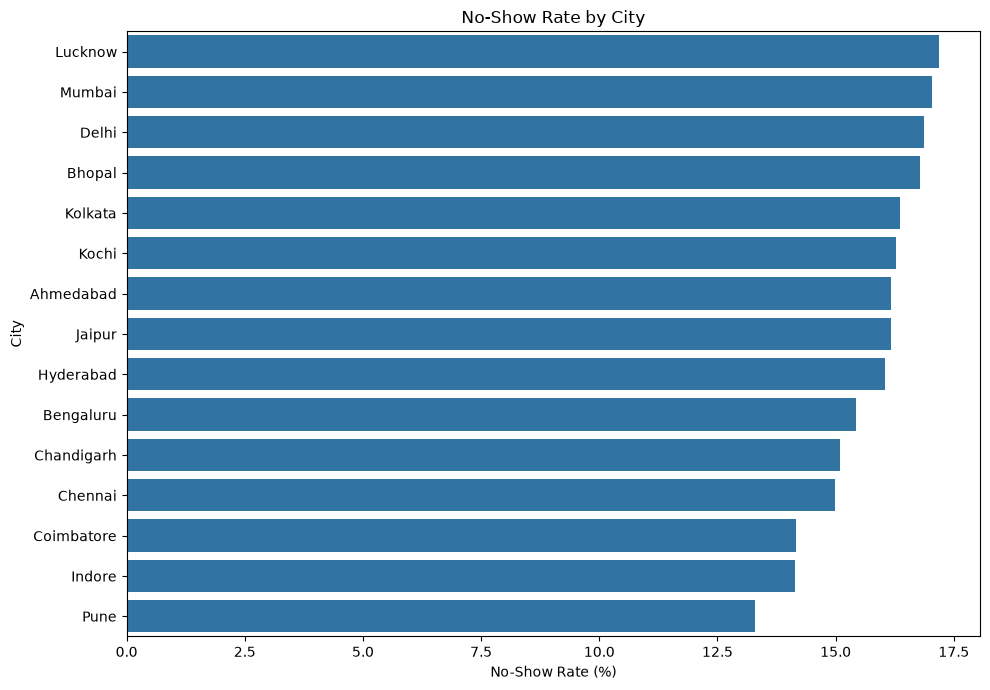

In [32]:
# No-show rate by city

plt.figure(figsize=(10, 7))

sns.barplot(
    data=city_no_show,
    x="no_show_rate_%",
    y="city_appointment"
)

plt.title("No-Show Rate by City")
plt.xlabel("No-Show Rate (%)")
plt.ylabel("City")

plt.tight_layout()
plt.show()

In [33]:
# No-show rate by booking lead days

lead_no_show = (
    df[df["appointment_status"].isin(
        ["Completed", "No-Show", "Cancelled"]
    )]
    .groupby("booking_lead_days")
    .agg(
        total_eligible_appointments=("appointment_id", "count"),
        no_show_count=("appointment_status", lambda x: (x == "No-Show").sum())
    )
    .reset_index()
)

lead_no_show["no_show_rate_%"] = (
    lead_no_show["no_show_count"]
    / lead_no_show["total_eligible_appointments"]
) * 100

lead_no_show

,booking_lead_days,total_eligible_appointments,no_show_count,no_show_rate_%
0,0,20180,3193,15.822597
1,1,10453,1382,13.221085
2,2,8227,1202,14.610429
3,3,6795,1067,15.702723
4,4,5395,900,16.682113
5,5,4384,706,16.104015
6,6,3310,490,14.803625
7,7,2808,527,18.767806
8,8,2227,416,18.679838
9,9,1777,332,18.683174


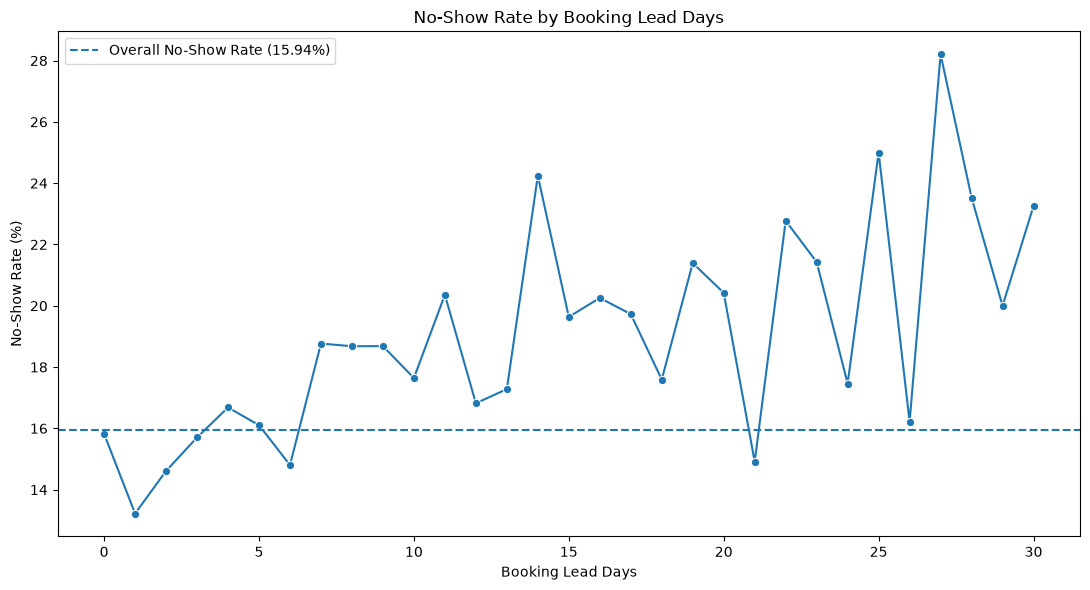

In [34]:
# No-show rate by booking lead days

plt.figure(figsize=(11, 6))

sns.lineplot(
    data=lead_no_show,
    x="booking_lead_days",
    y="no_show_rate_%",
    marker="o"
)

plt.axhline(
    y=15.94,
    linestyle="--",
    label="Overall No-Show Rate (15.94%)"
)

plt.title("No-Show Rate by Booking Lead Days")
plt.xlabel("Booking Lead Days")
plt.ylabel("No-Show Rate (%)")
plt.legend()

plt.tight_layout()
plt.show()

In [35]:
# No-show rate by time of day

time_no_show = (
    df[df["appointment_status"].isin(
        ["Completed", "No-Show", "Cancelled"]
    )]
    .groupby("time_of_day")
    .agg(
        total_eligible_appointments=("appointment_id", "count"),
        no_show_count=("appointment_status", lambda x: (x == "No-Show").sum())
    )
    .reset_index()
)

time_no_show["no_show_rate_%"] = (
    time_no_show["no_show_count"]
    / time_no_show["total_eligible_appointments"]
) * 100

time_no_show = time_no_show.sort_values(
    "no_show_rate_%",
    ascending=False
)

time_no_show

,time_of_day,total_eligible_appointments,no_show_count,no_show_rate_%
1,Evening,14553,2673,18.367347
0,Afternoon,23231,4124,17.752142
2,Morning,34868,4787,13.728921


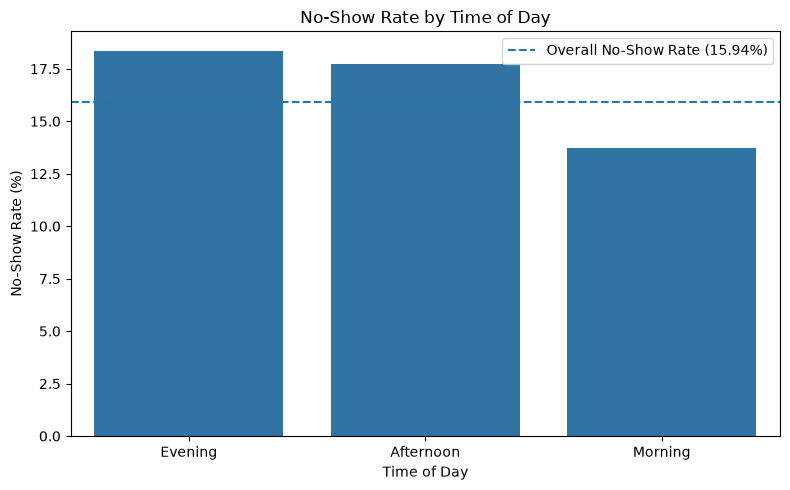

In [36]:
# No-show rate by time of day

plt.figure(figsize=(8, 5))

sns.barplot(
    data=time_no_show,
    x="time_of_day",
    y="no_show_rate_%"
)

plt.axhline(
    y=15.94,
    linestyle="--",
    label="Overall No-Show Rate (15.94%)"
)

plt.title("No-Show Rate by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("No-Show Rate (%)")
plt.legend()

plt.tight_layout()
plt.show()

In [37]:
# Weekend vs Weekday No-show Rate

df["day_type"] = np.where(
    df["appointment_day_of_week"].isin([5, 6]),
    "Weekend",
    "Weekday"
)

day_type_no_show = (
    df[df["appointment_status"].isin(
        ["Completed", "No-Show", "Cancelled"]
    )]
    .groupby("day_type")
    .agg(
        total_eligible_appointments=("appointment_id", "count"),
        no_show_count=("appointment_status", lambda x: (x == "No-Show").sum())
    )
    .reset_index()
)

day_type_no_show["no_show_rate_%"] = (
    day_type_no_show["no_show_count"]
    / day_type_no_show["total_eligible_appointments"]
) * 100

day_type_no_show = day_type_no_show.sort_values(
    "no_show_rate_%",
    ascending=False
)

day_type_no_show

,day_type,total_eligible_appointments,no_show_count,no_show_rate_%
1,Weekend,20921,3908,18.679795
0,Weekday,51731,7676,14.838298


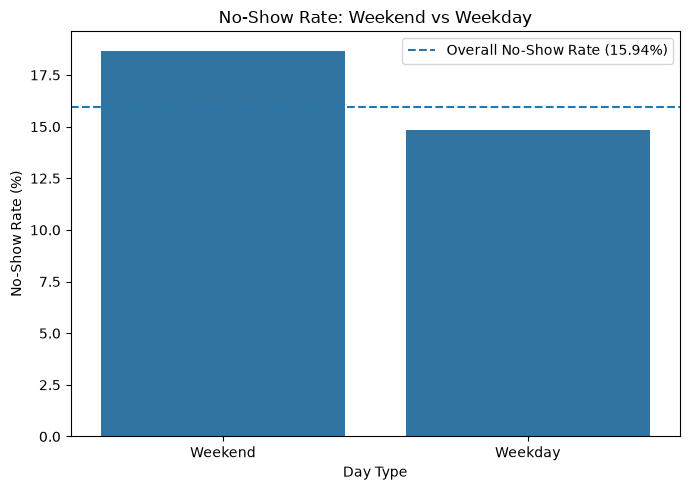

In [38]:
# Weekend vs Weekday No-show Rate

plt.figure(figsize=(7, 5))

sns.barplot(
    data=day_type_no_show,
    x="day_type",
    y="no_show_rate_%"
)

plt.axhline(
    y=15.94,
    linestyle="--",
    label="Overall No-Show Rate (15.94%)"
)

plt.title("No-Show Rate: Weekend vs Weekday")
plt.xlabel("Day Type")
plt.ylabel("No-Show Rate (%)")
plt.legend()

plt.tight_layout()
plt.show()

### Insight – Weekend vs Weekday No-Show

Weekend appointments have a higher no-show rate of 18.68% compared with 14.84% for weekday appointments.

This represents a difference of approximately 3.84 percentage points, indicating that weekend appointments are more prone to no-shows.

### Business Implication
Apollo Hospitals can consider stronger reminder strategies for weekend appointments, such as additional WhatsApp/SMS reminders or confirmation calls before the appointment.

In [39]:
appointment_type_no_show = (
    df[df["appointment_status"].isin(
        ["Completed", "No-Show", "Cancelled"]
    )]
    .groupby("appointment_type")
    .agg(
        total_eligible_appointments=("appointment_id", "count"),
        no_show_count=("appointment_status", lambda x: (x == "No-Show").sum())
    )
    .reset_index()
)

appointment_type_no_show["no_show_rate_%"] = (
    appointment_type_no_show["no_show_count"]
    / appointment_type_no_show["total_eligible_appointments"]
    * 100
)

appointment_type_no_show = appointment_type_no_show.sort_values(
    "no_show_rate_%",
    ascending=False
)

appointment_type_no_show

,appointment_type,total_eligible_appointments,no_show_count,no_show_rate_%
0,Home Visit,9742,2557,26.247177
2,Video Consult,15349,3232,21.056746
1,In-Clinic,47561,5795,12.184353


### Insight – No-Show Rate by Appointment Type

Home Visit appointments have the highest no-show rate at 26.25%, followed by Video Consults at 21.06%.

In-Clinic appointments have the lowest no-show rate at 12.18%.

The no-show rate for Home Visits is approximately 14.06 percentage points higher than In-Clinic appointments.

### Business Implication

Apollo Hospitals should consider stronger confirmation and reminder mechanisms for Home Visit and Video Consult appointments, particularly before the scheduled appointment time.

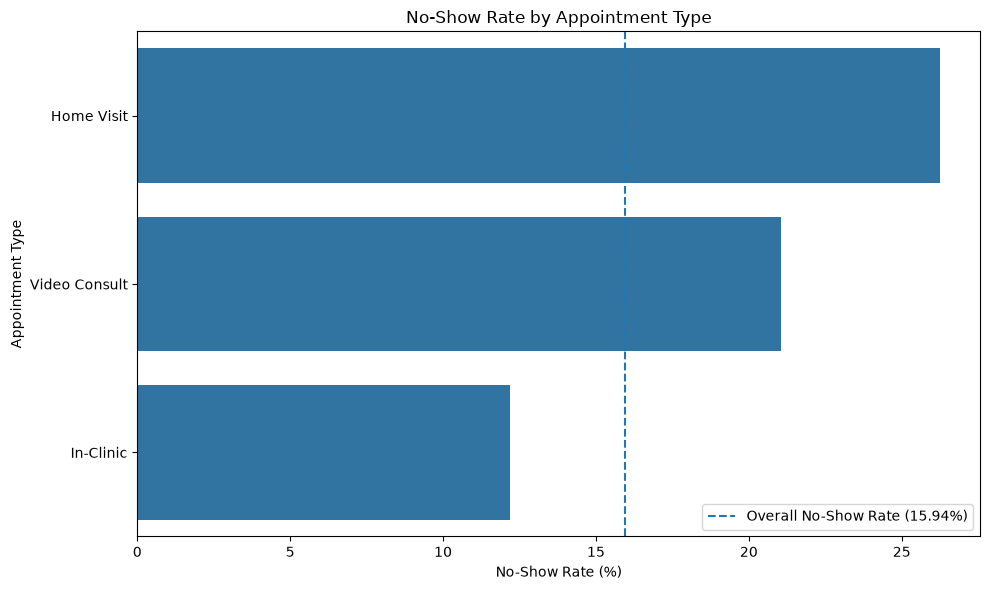

In [40]:
overall_no_show_rate = 15.94

plt.figure(figsize=(10, 6))

sns.barplot(
    data=appointment_type_no_show,
    x="no_show_rate_%",
    y="appointment_type"
)

plt.axvline(
    overall_no_show_rate,
    linestyle="--",
    label=f"Overall No-Show Rate ({overall_no_show_rate:.2f}%)"
)

plt.title("No-Show Rate by Appointment Type")
plt.xlabel("No-Show Rate (%)")
plt.ylabel("Appointment Type")
plt.legend()

plt.tight_layout()
plt.show()

In [41]:
# Reminder effectiveness analysis

reminder_analysis = (
    df[df["appointment_status"].isin(
        ["Completed", "No-Show", "Cancelled"]
    )]
    .groupby("reminder_type")
    .agg(
        total_eligible_appointments=("appointment_id", "count"),
        no_show_count=("appointment_status", lambda x: (x == "No-Show").sum())
    )
    .reset_index()
)

reminder_analysis["no_show_rate_%"] = (
    reminder_analysis["no_show_count"]
    / reminder_analysis["total_eligible_appointments"]
    * 100
)

reminder_analysis = reminder_analysis.sort_values(
    "no_show_rate_%",
    ascending=False
)

reminder_analysis

,reminder_type,total_eligible_appointments,no_show_count,no_show_rate_%
0,No Reminder,10977,3311,30.163068
3,SMS Only,14527,2363,16.266263
1,SMS + WhatsApp,25273,3414,13.508487
2,SMS + WhatsApp + Call,21875,2496,11.410286


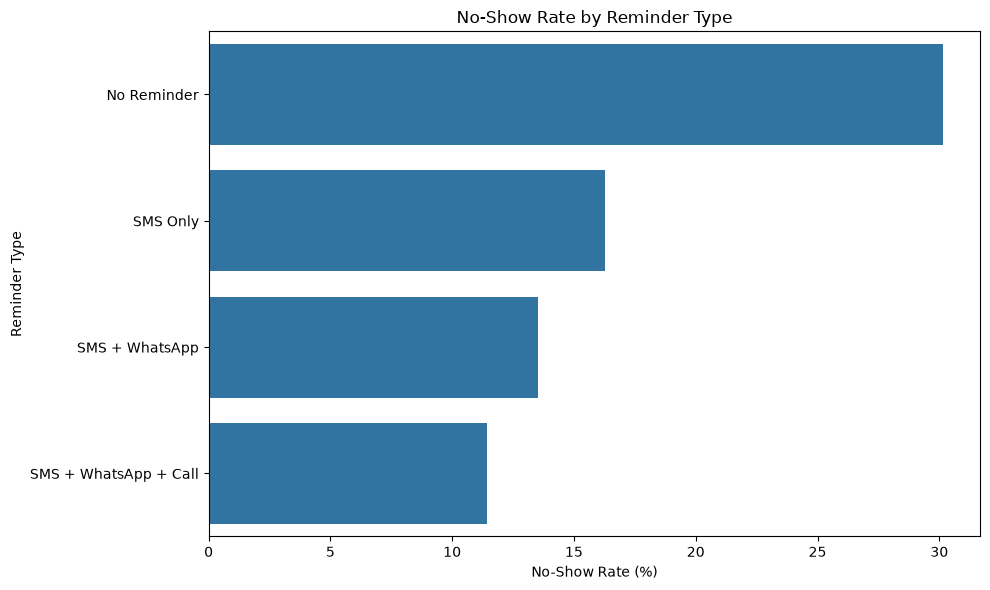

In [42]:
# Reminder effectiveness chart

plt.figure(figsize=(10, 6))

sns.barplot(
    data=reminder_analysis,
    x="no_show_rate_%",
    y="reminder_type"
)

plt.title("No-Show Rate by Reminder Type")
plt.xlabel("No-Show Rate (%)")
plt.ylabel("Reminder Type")

plt.tight_layout()
plt.show()

In [43]:
# Prior No-Show History Analysis

prior_no_show_analysis = (
    df[df["appointment_status"].isin(
        ["Completed", "No-Show", "Cancelled"]
    )]
    .groupby("patient_prior_no_shows")
    .agg(
        total_eligible_appointments=("appointment_id", "count"),
        no_show_count=("appointment_status", lambda x: (x == "No-Show").sum())
    )
    .reset_index()
)

prior_no_show_analysis["no_show_rate_%"] = (
    prior_no_show_analysis["no_show_count"]
    / prior_no_show_analysis["total_eligible_appointments"]
    * 100
)

prior_no_show_analysis

,patient_prior_no_shows,total_eligible_appointments,no_show_count,no_show_rate_%
0,0,63014,9549,15.153775
1,1,8502,1723,20.265820
2,2,983,262,26.653103
3,3,134,41,30.597015
4,4,16,8,50.000000
5,5,2,1,50.000000
6,6,1,0,0.000000


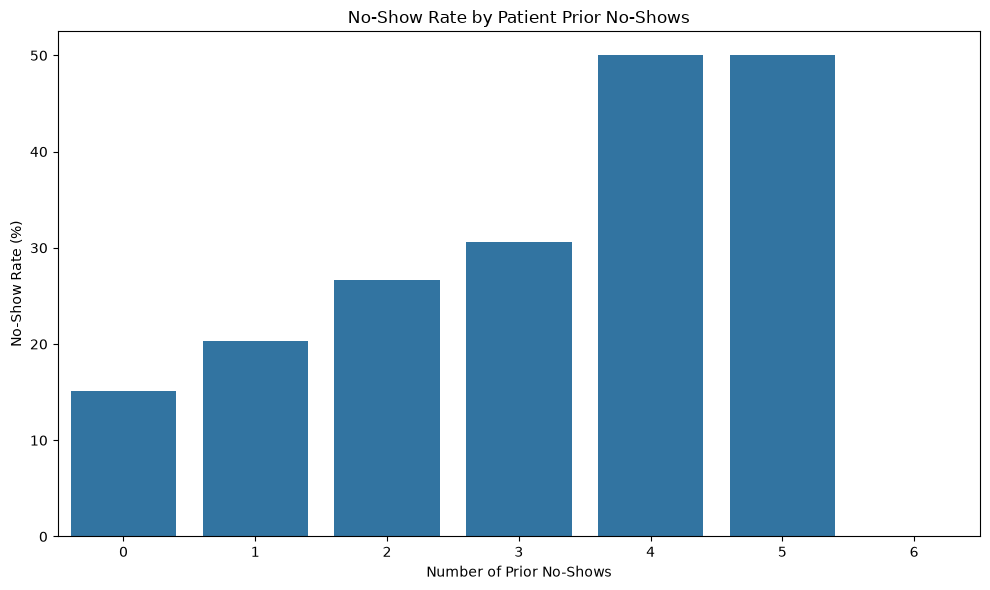

In [44]:
# Prior No-Show History Chart

plt.figure(figsize=(10, 6))

sns.barplot(
    data=prior_no_show_analysis,
    x="patient_prior_no_shows",
    y="no_show_rate_%"
)

plt.title("No-Show Rate by Patient Prior No-Shows")
plt.xlabel("Number of Prior No-Shows")
plt.ylabel("No-Show Rate (%)")

plt.tight_layout()
plt.show()

In [45]:
# Apollo Membership vs Non-Membership Analysis

membership_analysis = (
    df[df["appointment_status"].isin(
        ["Completed", "No-Show", "Cancelled"]
    )]
    .groupby("apollo_member")
    .agg(
        total_eligible_appointments=("appointment_id", "count"),
        no_show_count=("appointment_status", lambda x: (x == "No-Show").sum())
    )
    .reset_index()
)

membership_analysis["no_show_rate_%"] = (
    membership_analysis["no_show_count"]
    / membership_analysis["total_eligible_appointments"]
    * 100
)

membership_analysis

,apollo_member,total_eligible_appointments,no_show_count,no_show_rate_%
0,No,56428,9530,16.888779
1,Yes,16224,2054,12.660256


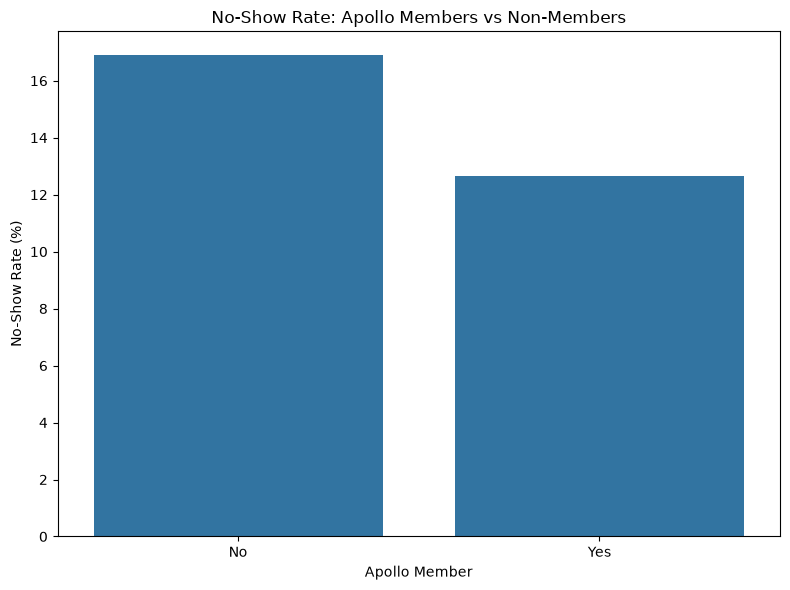

In [46]:
# Apollo Membership No-Show Rate Chart

plt.figure(figsize=(8, 6))

sns.barplot(
    data=membership_analysis,
    x="apollo_member",
    y="no_show_rate_%"
)

plt.title("No-Show Rate: Apollo Members vs Non-Members")
plt.xlabel("Apollo Member")
plt.ylabel("No-Show Rate (%)")

plt.tight_layout()
plt.show()

In [47]:
# First-Time vs Repeat Patient Analysis

repeat_visit_analysis = (
    df[df["appointment_status"].isin(
        ["Completed", "No-Show", "Cancelled"]
    )]
    .groupby("repeat_visit")
    .agg(
        total_eligible_appointments=("appointment_id", "count"),
        no_show_count=("appointment_status", lambda x: (x == "No-Show").sum())
    )
    .reset_index()
)

repeat_visit_analysis["no_show_rate_%"] = (
    repeat_visit_analysis["no_show_count"]
    / repeat_visit_analysis["total_eligible_appointments"]
    * 100
)

repeat_visit_analysis

,repeat_visit,total_eligible_appointments,no_show_count,no_show_rate_%
0,No,9182,6132,66.782836
1,Yes,63470,5452,8.589885


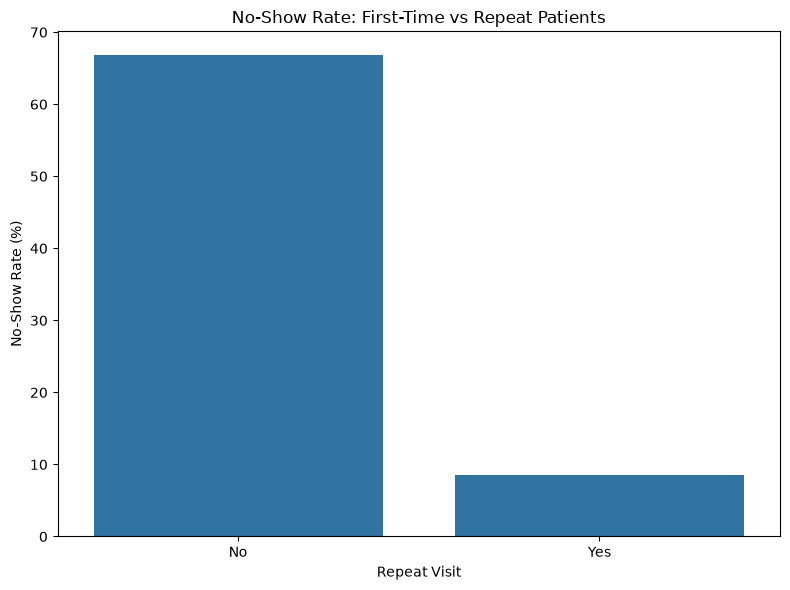

In [48]:
# First-Time vs Repeat Patient No-Show Rate Chart

plt.figure(figsize=(8, 6))

sns.barplot(
    data=repeat_visit_analysis,
    x="repeat_visit",
    y="no_show_rate_%"
)

plt.title("No-Show Rate: First-Time vs Repeat Patients")
plt.xlabel("Repeat Visit")
plt.ylabel("No-Show Rate (%)")

plt.tight_layout()
plt.show()

In [49]:
# Age Group vs No-Show Analysis

age_group_analysis = (
    df[df["appointment_status"].isin(
        ["Completed", "No-Show", "Cancelled"]
    )]
    .groupby("age_group")
    .agg(
        total_eligible_appointments=("appointment_id", "count"),
        no_show_count=("appointment_status", lambda x: (x == "No-Show").sum())
    )
    .reset_index()
)

age_group_analysis["no_show_rate_%"] = (
    age_group_analysis["no_show_count"]
    / age_group_analysis["total_eligible_appointments"]
    * 100
)

age_group_analysis

,age_group,total_eligible_appointments,no_show_count,no_show_rate_%
0,Adult (31-45),15133,2731,18.046653
1,Child (0-12),11745,1590,13.537676
2,Middle-aged (46-60),14862,2491,16.760867
3,Senior (60+),14516,2036,14.025902
4,Teen (13-18),6379,939,14.720176
5,Young Adult (19-30),10017,1797,17.939503


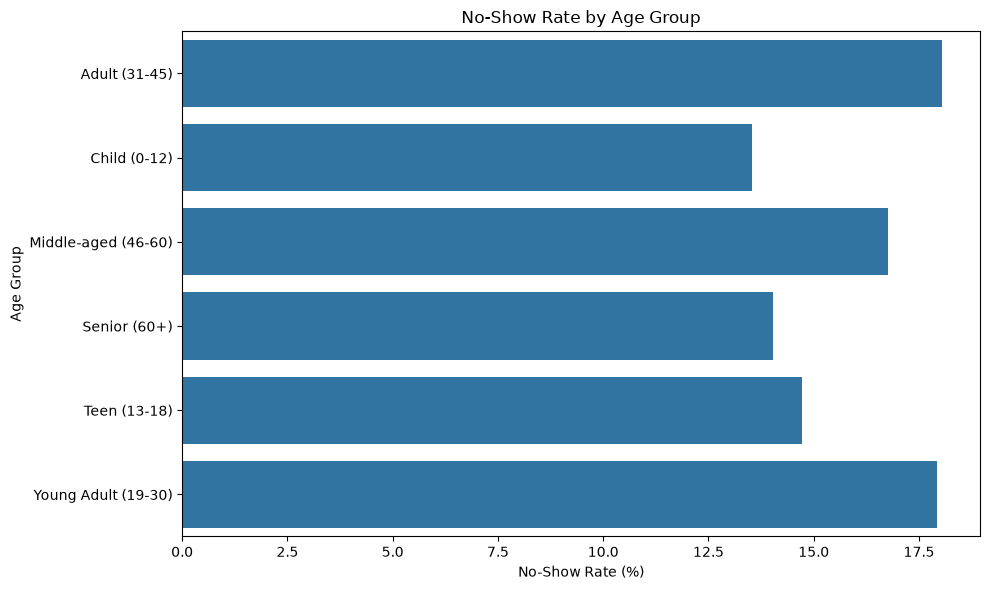

In [50]:
# Age Group No-Show Rate Chart

plt.figure(figsize=(10, 6))

sns.barplot(
    data=age_group_analysis,
    x="no_show_rate_%",
    y="age_group"
)

plt.title("No-Show Rate by Age Group")
plt.xlabel("No-Show Rate (%)")
plt.ylabel("Age Group")

plt.tight_layout()
plt.show()

In [51]:
# Gender vs No-Show Analysis

gender_analysis = (
    df[df["appointment_status"].isin(
        ["Completed", "No-Show", "Cancelled"]
    )]
    .groupby("patient_gender")
    .agg(
        total_eligible_appointments=("appointment_id", "count"),
        no_show_count=("appointment_status", lambda x: (x == "No-Show").sum())
    )
    .reset_index()
)

gender_analysis["no_show_rate_%"] = (
    gender_analysis["no_show_count"]
    / gender_analysis["total_eligible_appointments"]
    * 100
)

gender_analysis

,patient_gender,total_eligible_appointments,no_show_count,no_show_rate_%
0,Female,37589,6029,16.039267
1,Male,35063,5555,15.842911


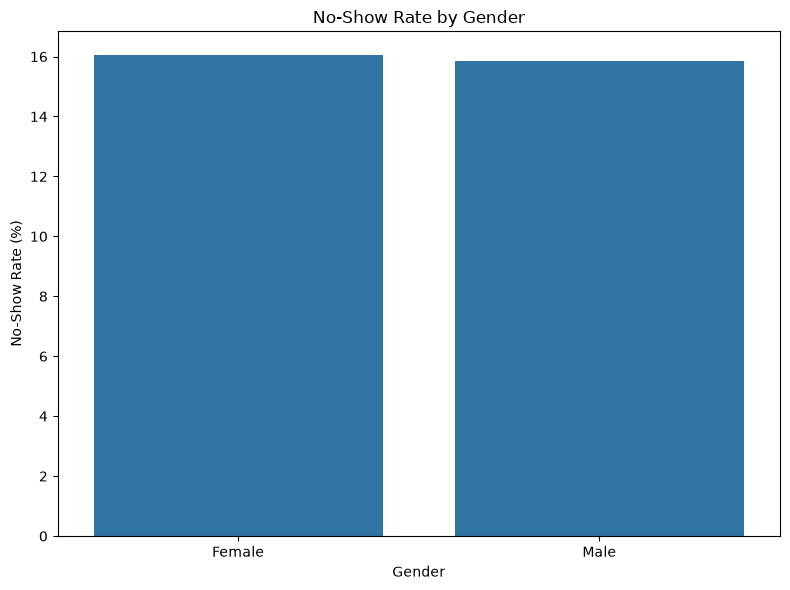

In [52]:
# Gender No-Show Rate Chart

plt.figure(figsize=(8, 6))

sns.barplot(
    data=gender_analysis,
    x="patient_gender",
    y="no_show_rate_%"
)

plt.title("No-Show Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("No-Show Rate (%)")

plt.tight_layout()
plt.show()

In [53]:
# Chronic Condition vs No-Show Analysis

chronic_condition_analysis = (
    df[df["appointment_status"].isin(
        ["Completed", "No-Show", "Cancelled"]
    )]
    .groupby("patient_chronic_condition")
    .agg(
        total_eligible_appointments=("appointment_id", "count"),
        no_show_count=("appointment_status", lambda x: (x == "No-Show").sum())
    )
    .reset_index()
)

chronic_condition_analysis["no_show_rate_%"] = (
    chronic_condition_analysis["no_show_count"]
    / chronic_condition_analysis["total_eligible_appointments"]
    * 100
)

chronic_condition_analysis

,patient_chronic_condition,total_eligible_appointments,no_show_count,no_show_rate_%
0,Asthma,9098,1520,16.706969
1,Diabetes,9010,1421,15.771365
2,Heart Disease,9155,1494,16.318951
3,Hypertension,9100,1417,15.571429
4,Hypothyroidism,9145,1418,15.505741


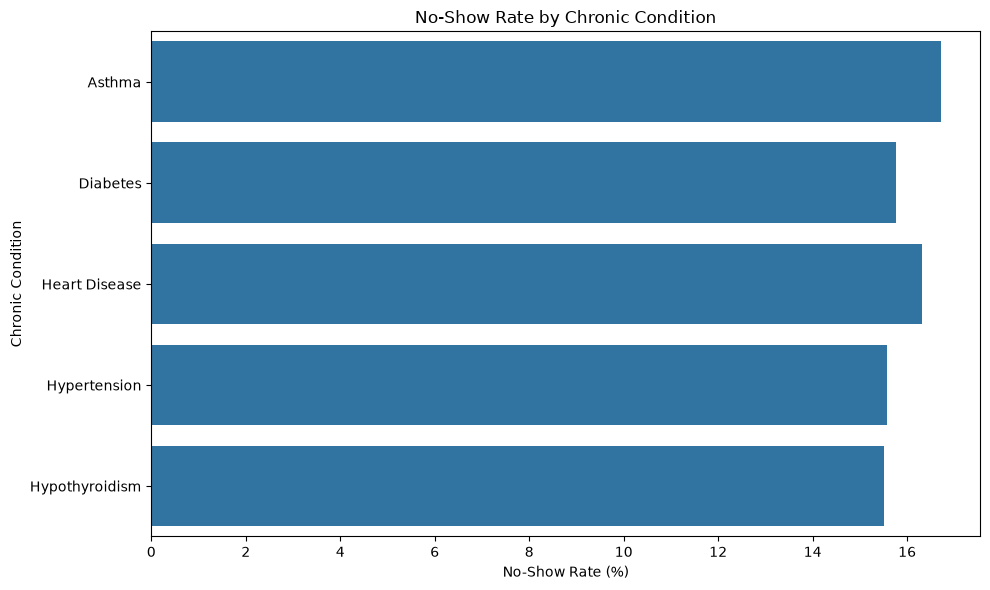

In [54]:
# Chronic Condition No-Show Rate Chart

plt.figure(figsize=(10, 6))

sns.barplot(
    data=chronic_condition_analysis,
    x="no_show_rate_%",
    y="patient_chronic_condition"
)

plt.title("No-Show Rate by Chronic Condition")
plt.xlabel("No-Show Rate (%)")
plt.ylabel("Chronic Condition")

plt.tight_layout()
plt.show()

In [55]:
# Visit Reason Analysis

visit_reason_analysis = (
    df["visit_reason"]
    .value_counts()
    .reset_index()
)

visit_reason_analysis.columns = [
    "visit_reason",
    "appointment_count"
]

visit_reason_analysis

,visit_reason,appointment_count
0,Follow-up,8807
1,Routine Checkup,8637
2,Chronic Condition Management,8380
3,Digestive Problem,8245
4,Fever & Infection,7041
5,Joint Pain,6664
6,Respiratory Issue,6590
7,Injury,6087
8,Eye Care,2959
9,Skin Issue,2862


In [56]:
# No-Show Rate by Visit Reason

visit_reason_no_show = (
    df[df["appointment_status"].isin(
        ["Completed", "No-Show", "Cancelled"]
    )]
    .groupby("visit_reason")
    .agg(
        total_eligible_appointments=("appointment_id", "count"),
        no_show_count=("appointment_status", lambda x: (x == "No-Show").sum())
    )
    .reset_index()
)

visit_reason_no_show["no_show_rate_%"] = (
    visit_reason_no_show["no_show_count"]
    / visit_reason_no_show["total_eligible_appointments"]
    * 100
)

visit_reason_no_show.sort_values(
    "no_show_rate_%",
    ascending=False
)

,visit_reason,total_eligible_appointments,no_show_count,no_show_rate_%
12,Skin Issue,2782,467,16.786485
8,Joint Pain,6469,1082,16.725924
0,Cardiac Concern,2639,430,16.294051
9,Mental Health,2733,445,16.282473
3,Digestive Problem,7984,1297,16.244990
7,Injury,5884,949,16.128484
5,Fever & Infection,6808,1095,16.084019
10,Respiratory Issue,6383,1020,15.979947
13,Women's Health,2362,377,15.961050
11,Routine Checkup,8377,1309,15.626119


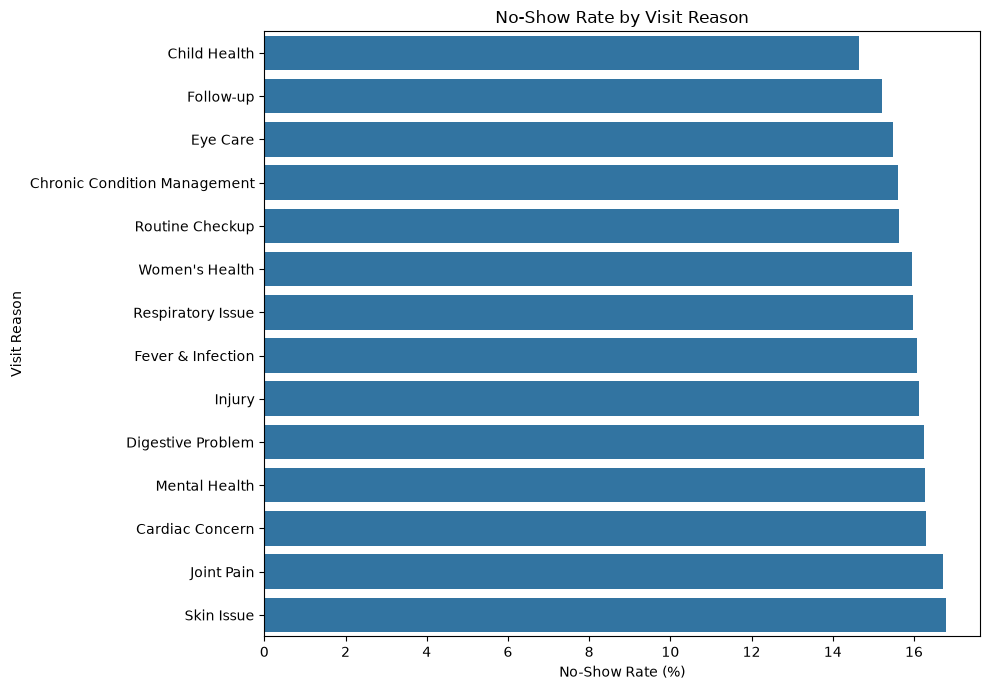

In [57]:
# No-Show Rate by Visit Reason

plt.figure(figsize=(10, 7))

sns.barplot(
    data=visit_reason_no_show.sort_values("no_show_rate_%", ascending=True),
    x="no_show_rate_%",
    y="visit_reason"
)

plt.title("No-Show Rate by Visit Reason")
plt.xlabel("No-Show Rate (%)")
plt.ylabel("Visit Reason")

plt.tight_layout()
plt.show()

In [58]:
# Patient Age Distribution by Selected Specialties

selected_specialties = [
    "Paediatrics",
    "Gynaecology",
    "Psychiatry"
]

age_distribution = df[
    df["specialty_appointment"].isin(selected_specialties)
][
    ["specialty_appointment", "patient_age"]
].copy()

age_distribution.groupby("specialty_appointment")["patient_age"].describe()

,count,mean,std,min,25%,50%,75%,max
specialty_appointment,,,,,,,,
Gynaecology,4113.0,41.689764,21.744012,1.0,25.0,42.0,59.0,85.0
Paediatrics,6382.0,9.251959,5.014363,1.0,5.0,9.0,14.0,18.0
Psychiatry,2989.0,41.964537,21.723190,1.0,25.0,42.0,59.0,85.0


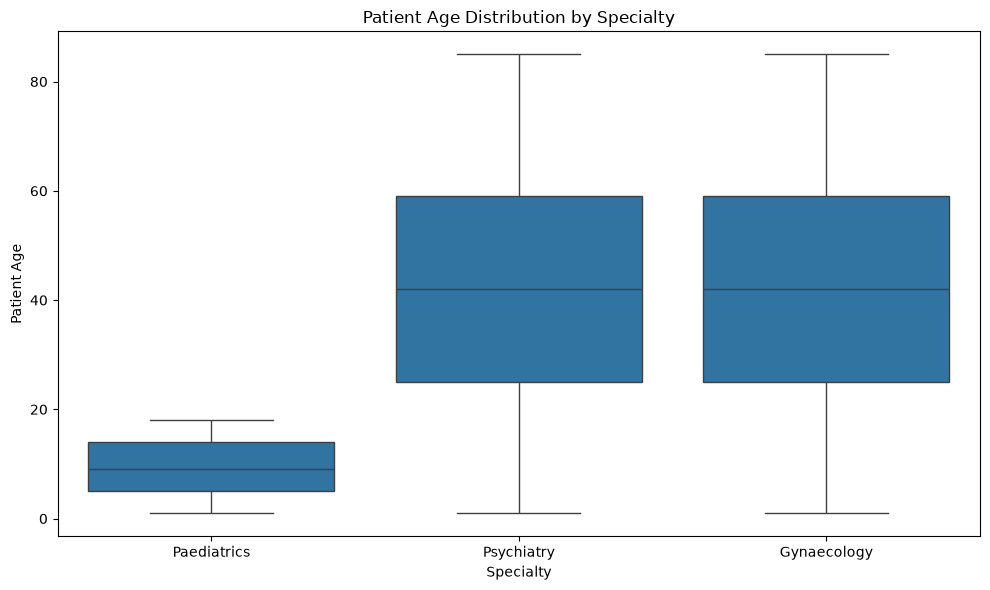

In [59]:
# Patient Age Distribution by Specialty

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=age_distribution,
    x="specialty_appointment",
    y="patient_age"
)

plt.title("Patient Age Distribution by Specialty")
plt.xlabel("Specialty")
plt.ylabel("Patient Age")

plt.tight_layout()
plt.show()

In [60]:
# Revenue Lost to No-Shows

no_show_revenue_loss = df[
    df["appointment_status"] == "No-Show"
]["consultation_fee_appointment"].sum()

no_show_revenue_loss

np.int64(19725460)

In [61]:
# Average Revenue by Specialty

avg_revenue_specialty = (
    df[df["appointment_status"] == "Completed"]
    .groupby("specialty_appointment")
    .agg(
        completed_appointments=("appointment_id", "count"),
        average_revenue=("revenue_realized", "mean")
    )
    .reset_index()
    .sort_values("average_revenue", ascending=False)
)

avg_revenue_specialty

,specialty_appointment,completed_appointments,average_revenue
11,Psychiatry,1958,2640.447906
7,Neurology,3899,2076.479354
13,Urology,1729,1988.621168
0,Cardiology,3507,1940.765326
4,Gastroenterology,1972,1896.815923
3,Endocrinology,1504,1812.684840
12,Pulmonology,1961,1803.229475
9,Orthopaedics,4189,1547.197899
6,Gynaecology,3134,1499.591895
8,Ophthalmology,2349,1467.125160


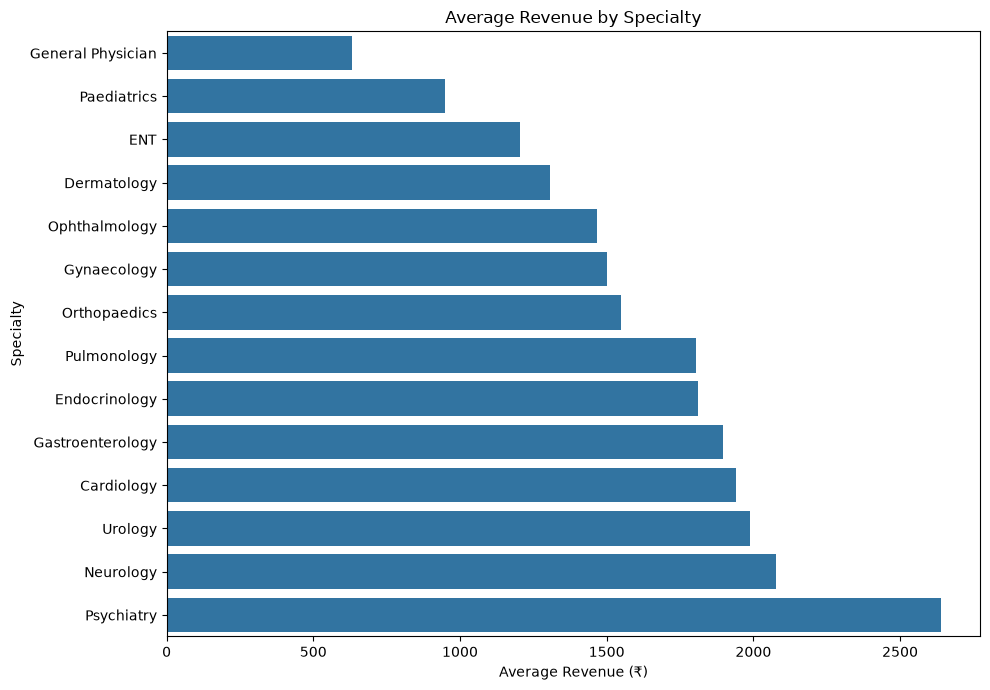

In [62]:
# Average Revenue by Specialty

plt.figure(figsize=(10, 7))

sns.barplot(
    data=avg_revenue_specialty.sort_values("average_revenue", ascending=True),
    x="average_revenue",
    y="specialty_appointment"
)

plt.title("Average Revenue by Specialty")
plt.xlabel("Average Revenue (₹)")
plt.ylabel("Specialty")

plt.tight_layout()
plt.show()

In [63]:
# Average Revenue by Appointment Type

avg_revenue_appointment_type = (
    df[df["appointment_status"] == "Completed"]
    .groupby("appointment_type")
    .agg(
        completed_appointments=("appointment_id", "count"),
        average_revenue=("revenue_realized", "mean")
    )
    .reset_index()
    .sort_values("average_revenue", ascending=False)
)

avg_revenue_appointment_type

,appointment_type,completed_appointments,average_revenue
0,Home Visit,6436,1960.048322
1,In-Clinic,37938,1299.829959
2,Video Consult,10901,1097.695441


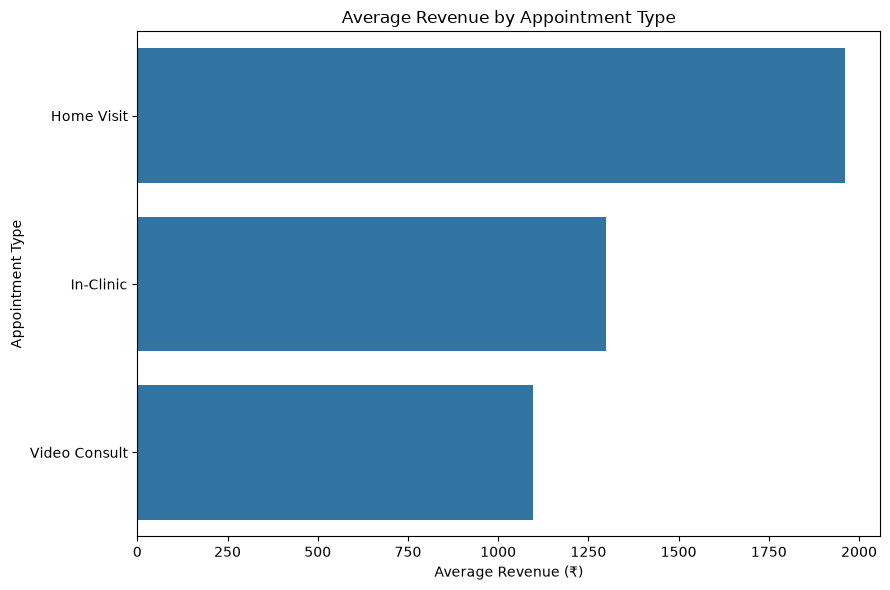

In [64]:
# Average Revenue by Appointment Type

plt.figure(figsize=(9, 6))

sns.barplot(
    data=avg_revenue_appointment_type,
    x="average_revenue",
    y="appointment_type"
)

plt.title("Average Revenue by Appointment Type")
plt.xlabel("Average Revenue (₹)")
plt.ylabel("Appointment Type")

plt.tight_layout()
plt.show()

In [65]:
# Top Revenue Cities

top_revenue_cities = (
    df[df["appointment_status"] == "Completed"]
    .groupby("city_appointment")
    .agg(
        completed_appointments=("appointment_id", "count"),
        total_revenue=("revenue_realized", "sum")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

top_revenue_cities

,city_appointment,completed_appointments,total_revenue
1,Bengaluru,6405,9990616
6,Delhi,7834,9958247
13,Mumbai,7318,8989613
7,Hyderabad,5496,7503245
4,Chennai,5132,7188473
11,Kolkata,4280,6543084
14,Pune,3179,4734139
0,Ahmedabad,2607,3956890
12,Lucknow,2254,3177444
8,Indore,1679,2223207


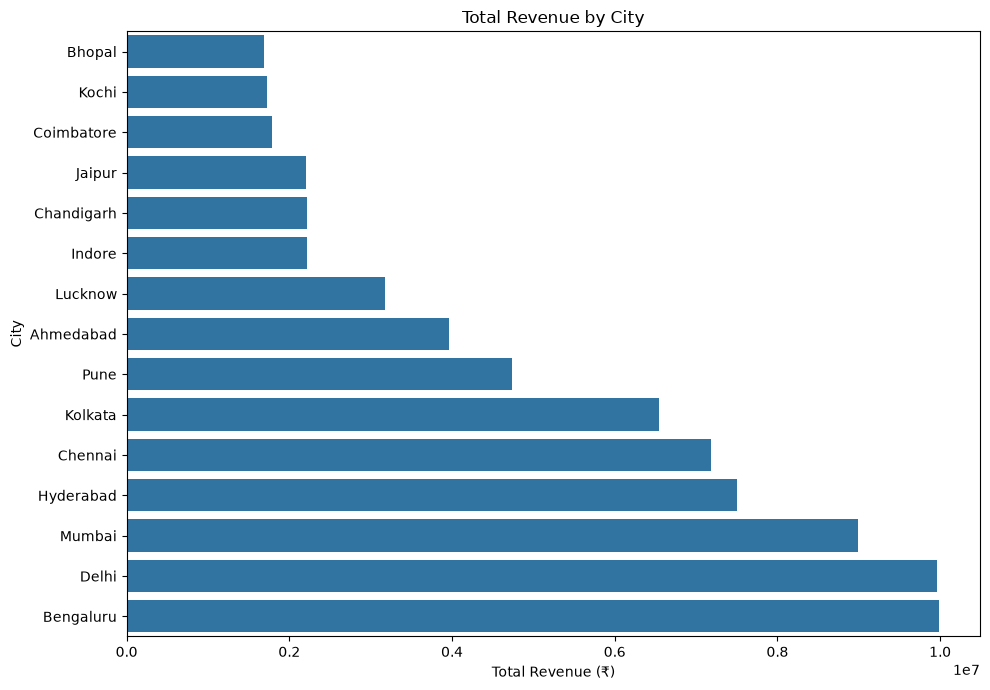

In [66]:
# Top Revenue Cities

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_revenue_cities.sort_values("total_revenue", ascending=True),
    x="total_revenue",
    y="city_appointment"
)

plt.title("Total Revenue by City")
plt.xlabel("Total Revenue (₹)")
plt.ylabel("City")

plt.tight_layout()
plt.show()

In [67]:
# Payment Mode Mix

payment_mode_mix = (
    df["payment_mode"]
    .value_counts()
    .reset_index()
)

payment_mode_mix.columns = [
    "payment_mode",
    "appointment_count"
]

payment_mode_mix["percentage_%"] = (
    payment_mode_mix["appointment_count"]
    / payment_mode_mix["appointment_count"].sum()
    * 100
)

payment_mode_mix

,payment_mode,appointment_count,percentage_%
0,Pending,19725,26.300000
1,Insurance,11641,15.521333
2,Debit Card,7353,9.804000
3,Net Banking,7349,9.798667
4,Apollo Pay,7324,9.765333
5,UPI,7259,9.678667
6,Credit Card,7213,9.617333
7,Cash,7136,9.514667


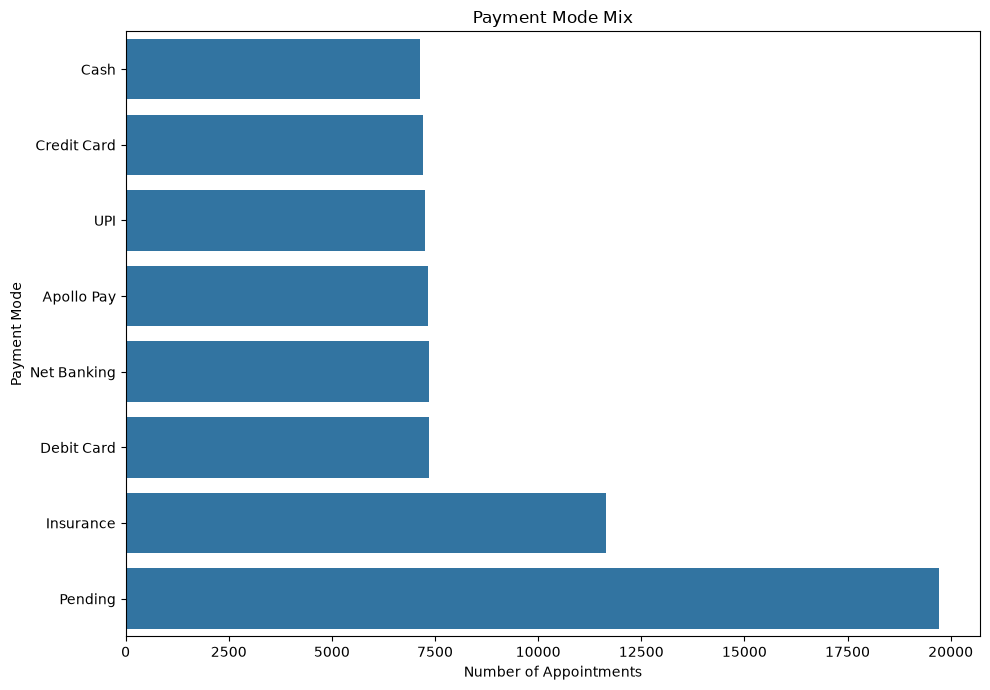

In [68]:
# Payment Mode Mix

plt.figure(figsize=(10, 7))

sns.barplot(
    data=payment_mode_mix.sort_values("appointment_count", ascending=True),
    x="appointment_count",
    y="payment_mode"
)

plt.title("Payment Mode Mix")
plt.xlabel("Number of Appointments")
plt.ylabel("Payment Mode")

plt.tight_layout()
plt.show()

In [69]:
# Insurance Coverage vs Out-of-Pocket

insurance_vs_outofpocket = (
    df[df["appointment_status"] == "Completed"]
    .agg(
        total_revenue=("revenue_realized", "sum"),
        insurance_covered=("insurance_covered_amount", "sum"),
        patient_out_of_pocket=("patient_out_of_pocket", "sum")
    )
    .reset_index()
)

insurance_vs_outofpocket

,index,revenue_realized,insurance_covered_amount,patient_out_of_pocket
0,total_revenue,73893798.0,NaN,NaN
1,insurance_covered,NaN,12376231.0,NaN
2,patient_out_of_pocket,NaN,NaN,73893798.0


In [70]:
# Insurance Coverage vs Out-of-Pocket Analysis

insurance_analysis = (
    df[df["appointment_status"] == "Completed"]
    .groupby("insurance_coverage")
    .agg(
        completed_appointments=("appointment_id", "count"),
        avg_insurance_covered=("insurance_covered_amount", "mean"),
        avg_out_of_pocket=("patient_out_of_pocket", "mean")
    )
    .reset_index()
)

insurance_analysis

,insurance_coverage,completed_appointments,avg_insurance_covered,avg_out_of_pocket
0,No,37523,0.000000,1562.820670
1,Yes,17752,697.173896,859.175192


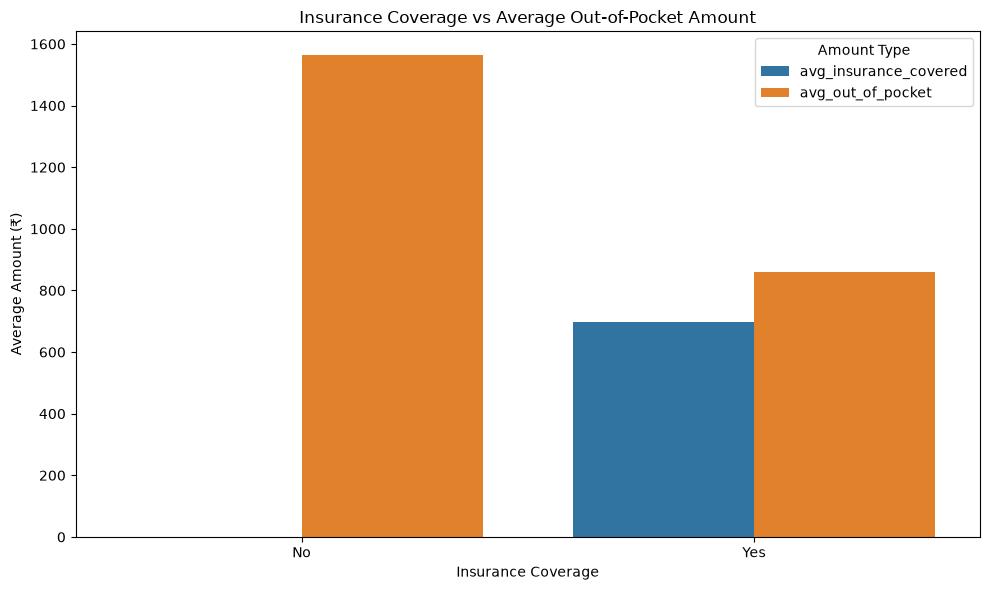

In [71]:
# Insurance Coverage vs Out-of-Pocket

insurance_chart = insurance_analysis.melt(
    id_vars="insurance_coverage",
    value_vars=["avg_insurance_covered", "avg_out_of_pocket"],
    var_name="payment_type",
    value_name="average_amount"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=insurance_chart,
    x="insurance_coverage",
    y="average_amount",
    hue="payment_type"
)

plt.title("Insurance Coverage vs Average Out-of-Pocket Amount")
plt.xlabel("Insurance Coverage")
plt.ylabel("Average Amount (₹)")
plt.legend(title="Amount Type")

plt.tight_layout()
plt.show()

In [72]:
# Doctor Utilization by Specialty

doctor_utilization = (
    df[df["appointment_status"] == "Completed"]
    .groupby("specialty_appointment")
    .agg(
        completed_appointments=("appointment_id", "count"),
        avg_doctor_utilization=("doctor_utilization_pct", "mean")
    )
    .reset_index()
    .sort_values("avg_doctor_utilization", ascending=False)
)

doctor_utilization

,specialty_appointment,completed_appointments,avg_doctor_utilization
4,Gastroenterology,1972,77.256288
3,Endocrinology,1504,77.146277
0,Cardiology,3507,76.814200
6,Gynaecology,3134,76.804531
10,Paediatrics,4900,76.664143
7,Neurology,3899,76.632342
5,General Physician,14981,76.590615
13,Urology,1729,76.442568
9,Orthopaedics,4189,76.430485
1,Dermatology,5347,76.420516


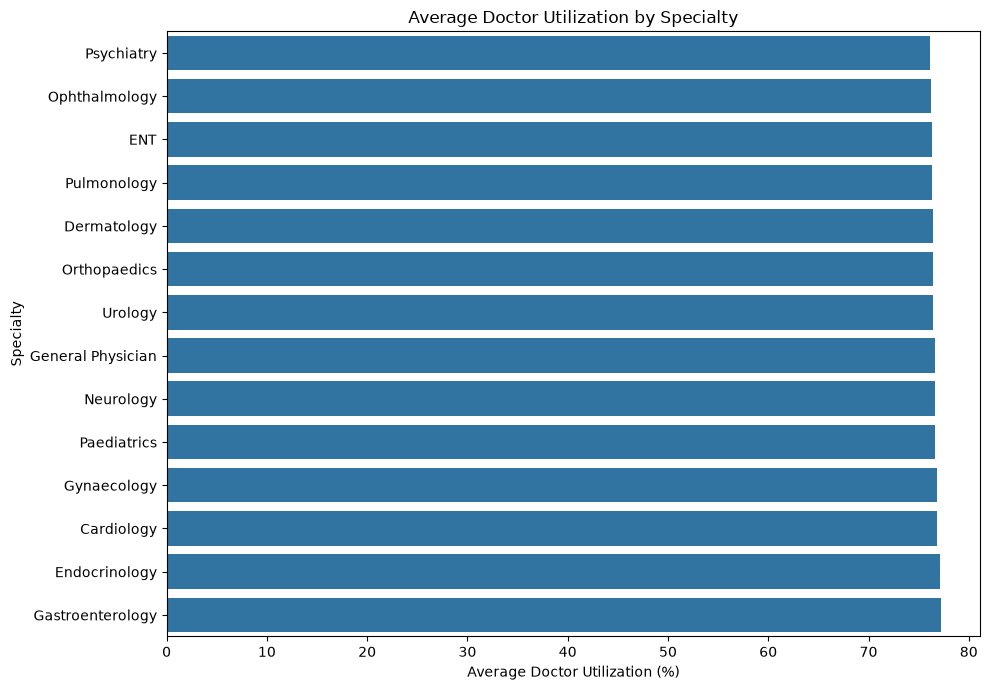

In [73]:
# Doctor Utilization by Specialty

plt.figure(figsize=(10, 7))

sns.barplot(
    data=doctor_utilization.sort_values("avg_doctor_utilization"),
    x="avg_doctor_utilization",
    y="specialty_appointment"
)

plt.title("Average Doctor Utilization by Specialty")
plt.xlabel("Average Doctor Utilization (%)")
plt.ylabel("Specialty")

plt.tight_layout()
plt.show()

In [74]:
# Wait Time by Specialty and Time of Day

wait_time_analysis = (
    df[df["appointment_status"] == "Completed"]
    .groupby(["specialty_appointment", "time_of_day"])
    .agg(
        completed_appointments=("appointment_id", "count"),
        avg_wait_time=("wait_time_minutes", "mean")
    )
    .reset_index()
)

wait_time_analysis

,specialty_appointment,time_of_day,completed_appointments,avg_wait_time
0,Cardiology,Afternoon,1107,11.875339
1,Cardiology,Evening,683,11.367496
2,Cardiology,Morning,1717,11.503203
3,Dermatology,Afternoon,1609,11.677439
4,Dermatology,Evening,1080,10.774074
5,Dermatology,Morning,2658,12.234011
6,ENT,Afternoon,1241,11.559226
7,ENT,Evening,753,11.330677
8,ENT,Morning,1851,11.109670
9,Endocrinology,Afternoon,463,11.095032


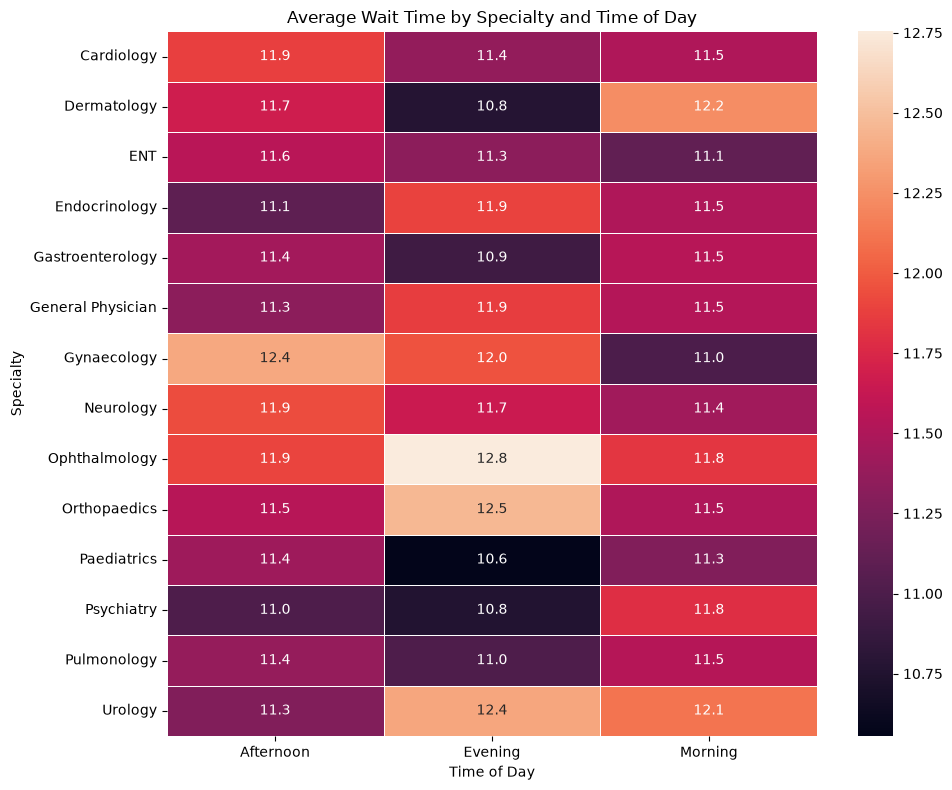

In [75]:
# Heatmap: Average Wait Time by Specialty and Time of Day

wait_time_pivot = wait_time_analysis.pivot(
    index="specialty_appointment",
    columns="time_of_day",
    values="avg_wait_time"
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    wait_time_pivot,
    annot=True,
    fmt=".1f",
    linewidths=0.5
)

plt.title("Average Wait Time by Specialty and Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Specialty")

plt.tight_layout()
plt.show()

In [76]:
# Consultation Duration vs Patient Satisfaction

consultation_satisfaction = df[
    df["appointment_status"] == "Completed"
][[
    "consultation_duration_min",
    "patient_satisfaction_score"
]].dropna()

consultation_satisfaction.describe()

,consultation_duration_min,patient_satisfaction_score
count,55275.000000,55275.000000
mean,18.439222,4.068092
std,8.634664,0.643663
min,5.000000,1.000000
25%,12.000000,3.600000
50%,17.000000,4.100000
75%,25.000000,4.600000
max,48.000000,5.000000


In [77]:
# Correlation between Consultation Duration and Patient Satisfaction

correlation = consultation_satisfaction[
    ["consultation_duration_min", "patient_satisfaction_score"]
].corr().iloc[0, 1]

print(f"Correlation: {correlation:.3f}")

Correlation: -0.004


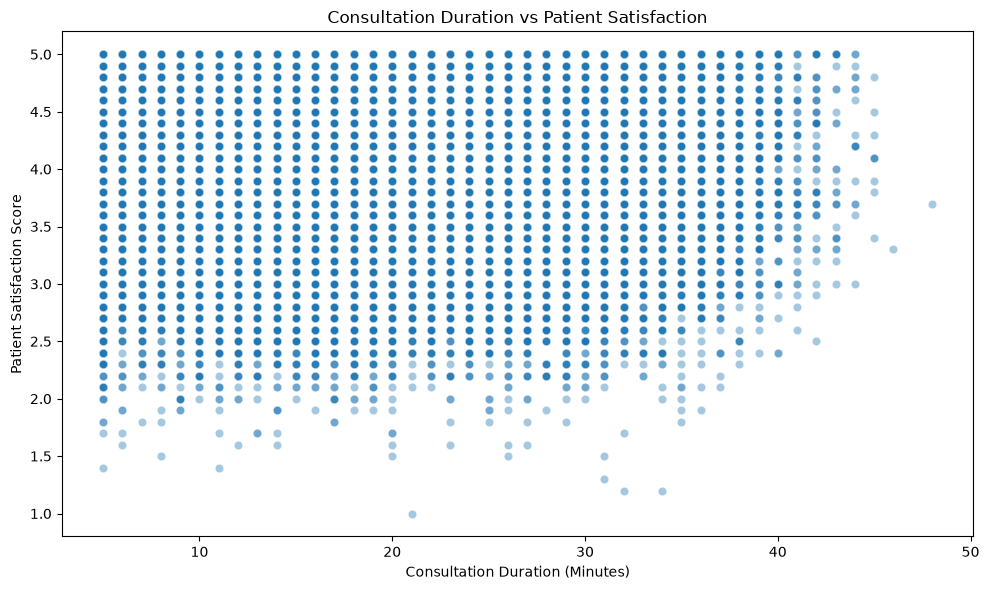

In [78]:
# Scatter Plot: Consultation Duration vs Patient Satisfaction

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=consultation_satisfaction,
    x="consultation_duration_min",
    y="patient_satisfaction_score",
    alpha=0.4
)

plt.title("Consultation Duration vs Patient Satisfaction")
plt.xlabel("Consultation Duration (Minutes)")
plt.ylabel("Patient Satisfaction Score")

plt.tight_layout()
plt.show()

In [79]:
# Doctor Experience vs Fee Charged

doctor_experience_fee = df[
    df["appointment_status"] == "Completed"
][[
    "experience_years",
    "actual_fee_charged"
]].dropna()

doctor_experience_fee.describe()

,experience_years,actual_fee_charged
count,55275.000000,55275.000000
mean,15.547499,1560.742270
std,8.684837,774.893548
min,2.000000,340.000000
25%,8.000000,900.000000
50%,16.000000,1500.000000
75%,23.000000,2000.000000
max,31.000000,5400.000000


In [80]:
# Correlation between Doctor Experience and Actual Fee Charged

experience_fee_correlation = doctor_experience_fee[
    ["experience_years", "actual_fee_charged"]
].corr().iloc[0, 1]

print(f"Correlation: {experience_fee_correlation:.3f}")

Correlation: 0.251


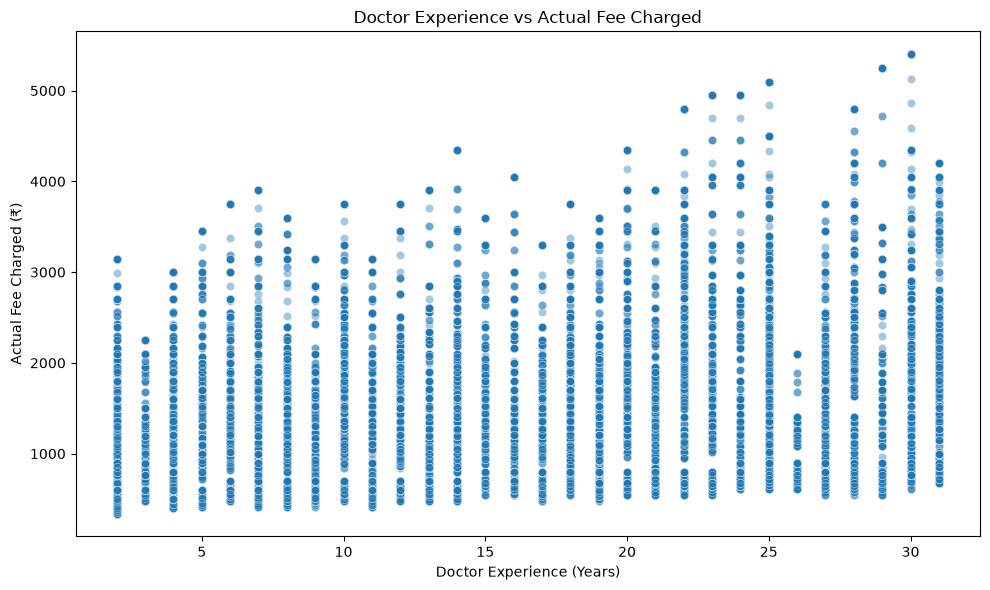

In [81]:
# Scatter Plot: Doctor Experience vs Actual Fee Charged

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=doctor_experience_fee,
    x="experience_years",
    y="actual_fee_charged",
    alpha=0.4
)

plt.title("Doctor Experience vs Actual Fee Charged")
plt.xlabel("Doctor Experience (Years)")
plt.ylabel("Actual Fee Charged (₹)")

plt.tight_layout()
plt.show()

# Key Findings

## Appointment & No-Show Insights
- Total appointments analyzed: 75,000 across 2022–2024.
- Overall no-show rate: 15.94% (excluding Scheduled appointments from the denominator).
- Walk-In appointments had the highest no-show rate at 20.88%, while Apollo App had the lowest at 14.18%.
- Psychiatry had the highest specialty-level no-show rate at 24.52%, while Neurology had the lowest at 10.69%.
- Lucknow recorded the highest city-level no-show rate at 17.19%, while Pune had the lowest at 13.30%.
- Weekend appointments had a higher no-show rate than weekday appointments.
- Evening appointments showed a higher no-show rate than morning appointments.
- Home Visits had the highest no-show rate among appointment types.

## Patient Engagement Insights
- Appointments without reminders had the highest observed no-show rate.
- Patients with previous no-shows generally showed higher current no-show rates.
- Apollo members had a lower observed no-show rate than non-members.
- Repeat patients had a substantially lower no-show rate than first-time patients.

## Patient & Demographic Insights
- The Adult age group recorded the highest no-show rate among the analyzed age groups.
- Female and male patients showed very similar no-show rates.
- Visit reasons showed relatively small variation in no-show rates.
- Paediatrics had a much younger patient age distribution compared with Gynaecology and Psychiatry.

## Financial Insights
- Estimated consultation-fee revenue associated with no-show appointments was approximately ₹1.97 crore.
- Psychiatry generated the highest average realized revenue per completed appointment.
- Home Visits had the highest average realized revenue among appointment types.
- Bengaluru recorded the highest total realized revenue, closely followed by Delhi.
- Pending was the largest payment-mode category.
- Insured completed appointments showed a lower average patient out-of-pocket amount than non-insured completed appointments.

## Doctor & Service Quality Insights
- Doctor utilization was relatively consistent across specialties.
- Average wait time varied only moderately across specialty and time-of-day combinations.
- Consultation duration showed almost no linear relationship with patient satisfaction (correlation = -0.004).
- Doctor experience showed a weak positive relationship with actual fee charged (correlation = 0.251).

# Business Recommendations

## 1. Reduce No-Shows Through Targeted Reminders
- Focus reminder campaigns on patients and appointment segments with higher no-show rates.
- Use SMS + WhatsApp + Call for higher-risk appointments where operationally feasible.
- Send reminders closer to the appointment date, especially for longer-lead bookings.

## 2. Improve Weekend and Evening Appointment Adherence
- Weekend and evening appointments show higher observed no-show rates.
- Use stronger reminder and confirmation processes for these time slots.
- Consider reconfirmation messages before high-risk appointments.

## 3. Focus on High-Risk Appointment Types
- Home Visits and Video Consults show higher observed no-show rates than In-Clinic appointments.
- Introduce additional confirmation steps for these appointment types.
- Monitor no-show trends by appointment type regularly.

## 4. Target First-Time and High-Risk Patients
- First-time patients show substantially higher no-show rates than repeat patients.
- Provide clear appointment instructions and confirmation messages to first-time patients.
- Patients with previous no-shows should receive additional engagement and reminder support.

## 5. Improve Performance in High No-Show Segments
- Psychiatry, Dermatology and ENT show relatively high no-show rates.
- Analyze operational factors within these specialties and consider targeted reminder strategies.
- City-level monitoring can help identify locations requiring additional intervention.

## 6. Reduce Revenue Impact of No-Shows
- No-show appointments represent approximately ₹1.97 crore in consultation-fee revenue exposure.
- Focus revenue-protection efforts on high no-show segments and higher-value appointment types.
- Monitor no-show-related revenue impact as a regular business KPI.

## 7. Monitor Payment Follow-Up
- Pending is the largest payment-mode category.
- Strengthen payment-status tracking and follow-up processes to reduce unresolved payment cases.

## 8. Maintain Service Quality Monitoring
- Doctor utilization is relatively consistent across specialties.
- Continue monitoring wait time by specialty and time of day.
- Consultation duration has almost no linear relationship with satisfaction, so satisfaction should be monitored using multiple service-quality factors rather than consultation duration alone.

# Conclusion

This exploratory data analysis of 75,000 Apollo Hospitals appointments from 2022–2024 provides a detailed view of appointment demand, patient engagement, no-show behavior, financial impact, and service quality.

The overall no-show rate was 15.94%, with noticeable differences across booking channels, specialties, cities, appointment types, time periods, reminder patterns, and patient engagement groups. Weekend, evening, home-visit, and first-time appointments showed higher observed no-show rates and therefore represent important areas for operational attention.

The analysis also identified a significant financial exposure from no-show appointments, estimated at approximately ₹1.97 crore based on consultation fees associated with no-show appointments. Revenue analysis showed differences across specialties, appointment types, and cities, while insurance coverage was associated with a lower average patient out-of-pocket amount.

From a service-quality perspective, doctor utilization remained relatively consistent across specialties. Consultation duration showed almost no linear relationship with patient satisfaction, while doctor experience had a weak positive relationship with actual fee charged.

Overall, the findings can help Apollo Hospitals improve appointment adherence, strengthen patient engagement, reduce revenue exposure from no-shows, and continuously monitor operational and service-quality performance.